# RECONSTRUCTING MIGRATORY MOVEMENTS FROM OTTOMAN CENSUS REGISTERS: AN AI-DRIVEN APPROACH

### Jhon G. Botello [![orcid](https://orcid.org/sites/default/files/images/orcid_16x16.png)](https://orcid.org/0009-0009-9344-4404) 
Virginia Modeling, Analysis, and Simulation Center, Old Dominion University, Norfolk, VA, USA

### Firuzan Melike Sümertaş [![orcid](https://orcid.org/sites/default/files/images/orcid_16x16.png)](https://orcid.org/0000-0002-7362-1487) 
Gennadius Library, American School of Classical Studies at Athens, Athens, Greece

### Jose J. Padilla [![orcid](https://orcid.org/sites/default/files/images/orcid_16x16.png)](https://orcid.org/0000-0003-0720-4148) 
Virginia Modeling, Analysis, and Simulation Center, Old Dominion University, Norfolk, VA, USA

### Christine Philliou [![orcid](https://orcid.org/sites/default/files/images/orcid_16x16.png)](https://orcid.org/0000-0001-5450-2557) 
Department of History, University of California, Berkeley, CA, USA

### Erika F. Frydenlund [![orcid](https://orcid.org/sites/default/files/images/orcid_16x16.png)](https://orcid.org/0000-0002-7694-7845) 
Virginia Modeling, Analysis, and Simulation Center, Old Dominion University, Norfolk, VA, USA

### Adam Anderson [![orcid](https://orcid.org/sites/default/files/images/orcid_16x16.png)]() 
Department of History, University of California, Berkeley, CA, USA

Recent advances in generative Artificial Intelligence (AI) are reshaping historical research by enabling new ways to access, process, and interpret archival materials. Our digital history study investigates how Large Language Models (LLMs) can assist in reconstructing migratory movements from Ottoman Empire–era census registers (referred throughout as defters). The analysis of these records has traditionally been a complex task due to their linguistic, structural, and temporal inconsistencies, including transliteration ambiguities, non-standardized formats, historical toponyms, and differing calendar systems. We show to what extent GPT-4o can extract, format, and geolocate historical geographic data, as well as perform Hijri-to-Gregorian calendar conversions. We systematically compared LLM outputs against modern geolocation and date conversion tools such as Geopy and an online date converter via an application programming interface (API). GPT-4o achieved nearly 90% accuracy in geolocating historical place names and outperformed Geopy by nearly 35%. Temporal validation showed that the LLM correctly converted 98% of years but struggled with month and day conversion. Using the resulting data, we analyzed migratory movements and patterns. Our findings contribute to current discussions about what LLMs know about history and highlight both the opportunities and methodological challenges of applying generative AI to historiography, offering a foundation for future AI-assisted workflows in digital history research and education.

Artificial Intelligence, Ottoman Census Registers, Migratory Movements, Geolocation, Digital History

[![cc-by](https://licensebuttons.net/l/by/4.0/88x31.png)](https://creativecommons.org/licenses/by/4.0/) 
©Jhon G. Botello, Firuzan Melike Sümertaş, Jose J. Padilla, Christine Philliou, Erika F. Frydenlund, Adam Anderson. Published by De Gruyter in cooperation with the University of Luxembourg Centre for Contemporary and Digital History. This is an Open Access article distributed under the terms of the [Creative Commons Attribution License CC-BY](https://creativecommons.org/licenses/by/4.0/)


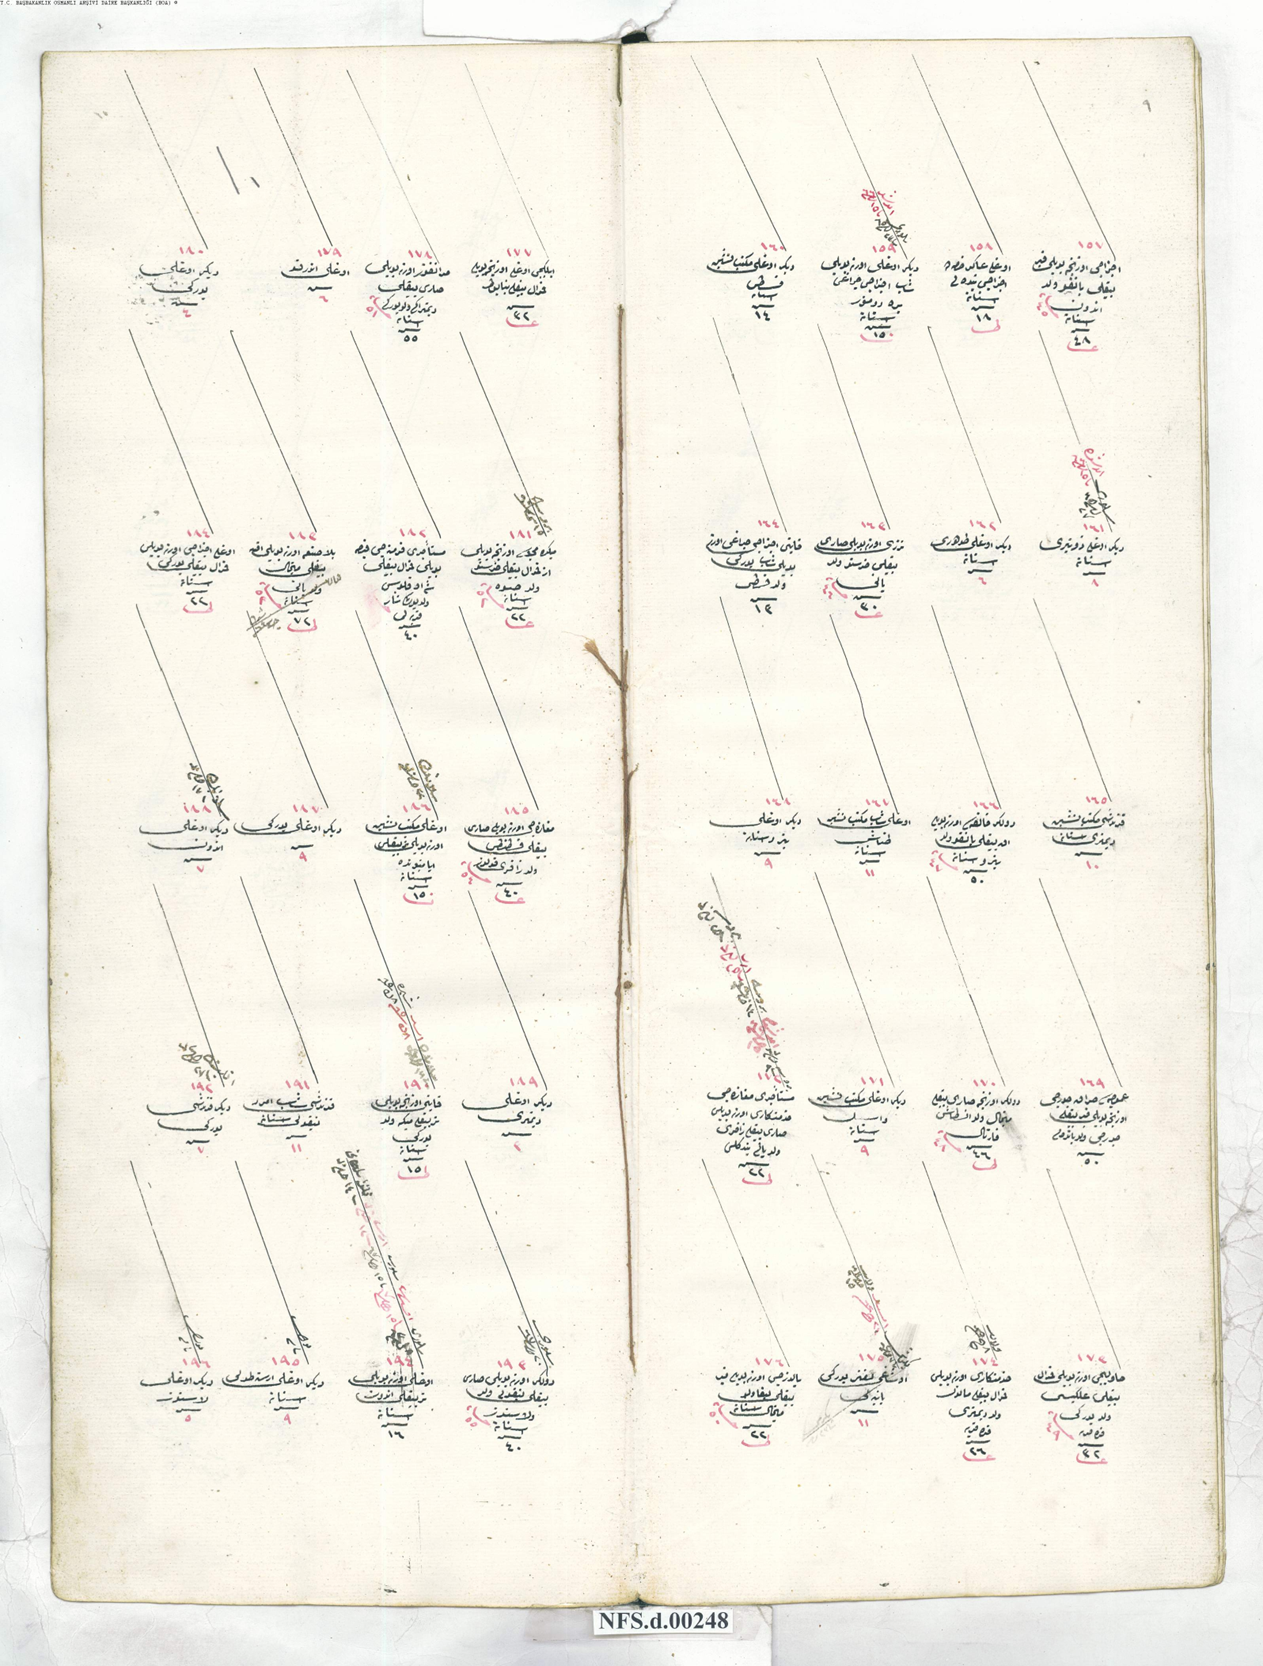

In [1]:
from IPython.display import Image, display
display(Image("./media/Cover_Defter.png"))

## Introduction

In recent years, generative Artificial Intelligence (AI) has shown its potential to transform historiographical practices, particularly in how scholars access, analyze, and represent the past <cite id="l993a"><a href="#zotero%7C21909901%2FRVLSLD94">(Clavert and Muller 2024)</a></cite>. This technological shift has opened new avenues and raised important questions about what AI can do and how it may be integrated within the field of history. Applications of AI in this field have included human and machine collaboration, where AI assists historians with tasks such as processing, generating, and analyzing historical sources <cite id="sqs2x"><a href="#zotero%7C21909901%2FG2FHPJHT">(Yao 2025)</a></cite>, historical fact-checking <cite id="mflid"><a href="#zotero%7C21909901%2FWNESWWCD">(Tasar and Tasar 2023)</a></cite>, and the automatic transcription and normalization of archival texts <cite id="e6u8n"><a href="#zotero%7C21909901%2FYZ7HCPRV">(Spina 2023)</a></cite>. Some researchers are also exploring what AI “knows” about the past (<cite id="9eoth"><a href="#zotero%7C21909901%2FVZEPVNV5">(Hutchinson 2022)</a></cite>, <cite id="oohgp"><a href="#zotero%7C21909901%2FTBDALWBZ">(Hutchinson 2024)</a></cite>), while others have examined its potential for history education <cite id="py7zm"><a href="#zotero%7C21909901%2FFBQTUXTC">(VanGorder 2025)</a></cite>. Despite these advances, further research is still needed to investigate how AI tools can be applied to enhance specific areas of historical research, particularly in contexts involving the reconstruction of complex spatial and temporal dynamics from transliterated and semi-structured data.

Ottoman census/population registers (referred throughout as defters), provide an exemplary case study for examining the intersection of AI and historical research. The defters we use for this study were administrative registers produced by the Ottoman Empire to document and manage its population for military, fiscal, and administrative purposes. These records often contain detailed demographic and geographic data, providing historians with a valuable source for reconstructing longitudinal and spatio-temporal patterns of migration and population movement across centuries of imperial governance.

Analyzing migration patterns and reconstructing population movements from defters has traditionally been a complex and labor-intensive task. Scholars typically transliterate these records from their original Arabic script into the Latin alphabet (similar to Turkish transcription) and categorize the information into digital spreadsheets for further computational analysis. However, the absence of standardization across these census registers, combined with periodic updates and marginalia by Ottoman state officials within the same documents, followed by the participation of multiple individuals in the transliteration and digitization process, has produced datasets—particularly those concerning demographics and migratory movements—that often appear in inconsistent, semi-structured formats. Moreover, the absence of vowels in Arabic script creates difficulties in transliterating certain words and in recording non-ambiguous information, leading to obstacles for subsequent computational analysis and a rather messy dataset. The above inconsistencies hinder large-scale systematic analysis, as different researchers may organize information differently and employ a variety of delimiters, such as commas, semicolons, or periods.

In addition to linguistic and structural challenges, historians face significant difficulties in identifying geographic locations and reconstructing timelines from the registers. Many entries reference historical toponyms that have changed names, disappeared, or correspond to multiple places, making geolocation a largely manual and interpretive task that requires expert knowledge, consultation of historical maps and texts, and manual searches using modern mapping tools. This process is especially time-consuming for large datasets and also results in inconsistencies across research teams and datasets. Chronological reconstruction presents a parallel difficulty, as dates are frequently recorded using abbreviated Hijri (lunar) months that differ from the Gregorian calendar used in contemporary analytical tools, resulting in inconsistent date representations that hinder temporal querying and require largely manual timeline reconstruction.

Traditional computational approaches, such as rule-based text extraction or digitally assisted geocoding and date conversion (<cite id="ylw3y"><a href="#zotero%7C21909901%2FJI6FW5CG">(Piotrowski 2012)</a></cite>, <cite id="amhg6"><a href="#zotero%7C21909901%2FBFL9ACDI">(Ehrmann et al. 2024)</a></cite>, <cite id="ob5x7"><a href="#zotero%7C21909901%2FK887D4AQ">(Stangl et al. 2025)</a></cite>), often struggle to accommodate the historical, linguistic, and structural variability/inconsistency inherent in historical documents, such as defters. As a result, efforts to reconstruct migratory movements from these registers have remained largely descriptive and limited in scale. Recent advances in generative AI, however, offer new possibilities for overcoming the limitations. Large Language Models (LLMs), in particular, are capable of interpreting semi-structured data, understanding historical context derived from training corpora, and performing tasks that require contextual reasoning. These capabilities make LLMs valuable tools for enhancing historical research in the defter domain, potentially supporting tasks such as data extraction and formatting from transliterated and digitized sources, historical geolocation, and date conversion. Testing the extent of LLMs' ability to perform such tasks can provide insights into what these models know about defters and how they might augment traditional analytical workflows by enabling more accurate, reproducible, and scalable methods of data extraction, contextualization, and interpretation.

Our digital history study investigates how LLMs can assist in reconstructing migratory movements from Ottoman census registers. Focusing on two sets of defters kept in the State Archives in Turkey, in Istanbul,  (On Fener: BOA NFS_d__00230 ca. 1845, On Tatavla: BOA NFS_d__00248, ca. 1845) documenting the demographics and movements of the male members of the Greek Orthodox community in Istanbul from the early to mid-nineteenth century (circa 1830s–1850s), we explore the ability of GPT-4o to extract and format demographic and geographic information; assign spatial coordinates to historical place names absent from modern databases; and convert calendar references. We manually evaluated the LLM's performance through systematic comparisons with Geopy, a contemporary geolocation tool, and assessed its temporal conversion accuracy against an established date-conversion API. By conducting statistical analyses and visualizations, and by discussing how the cleaned and structured data can be integrated into FactGrid—a collaborative Wikibase designed for historical research—we show how AI-assisted workflows can advance archival preservation, enable semantic querying, and support spatial and temporal analysis in digital history. Ultimately, our study highlights both the opportunities and methodological challenges of incorporating generative AI into historical research, paving the way toward agentic AI systems capable of automating end-to-end integration across analytical, mapping, and database environments within the field of history.

## Background

### Ottoman Census Registers (Defters)

Throughout much of its history, the Ottoman administration maintained administrative, fiscal, and demographic record books generally referred to as defters, meaning registers or notebooks in Turkish. Earlier forms, such as the tahrir defterleri, were used to record lands, properties, and tax obligations following conquest within the framework of the timar system <cite id="lo54q"><a href="#zotero%7C21909901%2FUPKJMW38">(Coşgel 2004)</a></cite>. During the nineteenth century, however, Ottoman record-keeping practices underwent a major transformation as the state sought to establish a more systematic population registration system. Sultan Mahmud II initiated the first modern census in 1831 to support military conscription and tax reform following the abolition of the Janissary Corps <cite id="55o3j"><a href="#zotero%7C21909901%2F2NLNPWRF">(Shaw 1978)</a></cite>, giving rise to the nüfus defterleri, or population registers. These censuses classified the population by religion and, among Muslims, by age group, while non-Muslims were categorized according to wealth for the assessment of cizye (poll tax) obligations.

The institutionalization of census-taking accelerated with the establishment of a Census Department in 1835. According to <cite id="ekmri"><a href="#zotero%7C21909901%2FVVTNMLYJ">(Şaşmaz 1995)</a></cite>, local officials, guild leaders, and representatives of religious communities participated in recording demographic events such as births, deaths, and migrations. Earlier registers from the 1820s sometimes included prefatory texts identifying the individuals responsible for conducting the surveys, including military personnel, clergy, guild leaders, and administrative officials. In the more standardized registers produced from 1839 onward, however, individual census-takers are not always explicitly identified. Nevertheless, the increasing uniformity of these records reflects the broader institutionalization and standardization of Ottoman population registration practices during the nineteenth century. These registers typically recorded an individual's name, father's name, occupation, place of origin, age, and tax category, while organizing individuals by household and neighborhood. They were also updated over several years to document births, deaths, and migration events <cite id="man1"><a href="#erunal2021">(Erünal 2021)</a></cite>. By the late nineteenth century, successive reforms had produced a more standardized and efficient registration system, reflecting broader efforts to strengthen administrative control, fiscal management, and knowledge of the empire's population across provinces (vilayets), districts (sanjaks), counties (kazas), and localities (nahiyes) <cite id="q7k98"><a href="#zotero%7C21909901%2FVVTNMLYJ">(Şaşmaz 1995)</a></cite>. 

The information collected also reflected the administrative purposes of each census. Earlier surveys could be conducted for purposes such as identifying guarantors, monitoring weapons, documenting guild membership, or estimating food requirements, whereas the more regularized surveys beginning around 1839 were closely connected to taxation, particularly the cizye paid by non-Muslim subjects. These administrative objectives shaped both the categories recorded and the populations included. Women, for example, were generally excluded from these registers, while population registers were often organized separately by religious community. Census-taking also faced practical challenges, including reluctance among some populations to be registered, incomplete or inaccurate updating of records, and difficulties ensuring consistent reporting across localities <cite id="q7k98"><a href="#zotero%7C21909901%2FVVTNMLYJ">(Şaşmaz 1995)</a></cite>. At the same time, some aspects of enumeration remain difficult to reconstruct, particularly how self-reported information was negotiated between individuals and census officials in practice. Although cizye categories were formally based on ability to pay and could rely on declarations of wealth, the extent to which such categories or information such as place of origin were negotiated during individual encounters is less clear in the literature.

As noted above, defters often contain detailed information such as names, ages, religions, occupations, marital status, health conditions, places of origin, and records of movement, including locations and dates. These details make the registers valuable sources for historians seeking to study the social, demographic, and population dynamics of the late Ottoman Empire. For consistency, we refer to nüfus defterleri simply as “defters” throughout this study, as they constitute our primary data source.

Regarding the use of defters in research studies, foundational works<sup><a href="#fn1" id="ref1">1</a></sup> by <cite id="mjz7j"><a href="#zotero%7C21909901%2F2NLNPWRF">(Shaw 1978)</a></cite> and <cite id="xmgle"><a href="#zotero%7C21909901%2FETH3PCDP">(Karpat 1978)</a></cite>, for instance, relied primarily on manual examination and historical-documentary methods to assess the reliability of defters and to interpret broader patterns of administrative modernization and population movement within the Ottoman Empire. With the rise of digital history, more recent research has increasingly emphasized the transliteration, digitization, quantitative analysis, and computational modeling of Ottoman population data, enabling scholars to revisit defters through digital and data-driven approaches. For example, <cite id="edvrp"><a href="#zotero%7C21909901%2FWXMNZU39">(Kabadayı and Erünal 2024)</a></cite> undertook a major effort to manually extract, transliterate, and digitize data from handwritten defters documenting the city of Bursa between 1839 and 1843. The authors organized the information into a relational database linking households and individuals, thereby transforming non-tabulated archival records into a structured, interoperable format that enables new quantitative analyses of Ottoman population data. Similarly, researchers affiliated with the IstanΠόλις Collaborative Project<sup><a href="#fn2" id="ref2">2</a></sup> at the University of California, Berkeley, are deciphering and tabulating nineteenth-century defters of the Greek Orthodox (Rum) communities of Istanbul. Their work focuses on transliteration, data cleaning, and the creation of open-access datasets that preserve male name lists, household structures, occupations, places of origin, and movements, with the aim of developing interactive spatial visualizations that map individuals’ residences, migrations, and workplaces over time.

<hr>

<ol>
  <li id="fn1">For other foundational studies on the Ottoman census registers, see <cite id="mr3oc"><a href="#zotero%7C21909901%2F6RRKF45S">(Karal 1943)</a></cite>, <cite id="joprr"><a href="#zotero%7C21909901%2FETH3PCDP">(Karpat 1978)</a></cite>, and <cite id="dm98a"><a href="#zotero%7C21909901%2FZP649KDV">(Behar 2011)</a></cite>.
      <a href="#ref1"></a>
  </li>
  <li id="fn2"><a href="https://www.istanpolis.org">https://www.istanpolis.org</a>
      <a href="#ref2"></a>
  </li>
</ol>



While historians make significant progress in converting defters into structured digital formats, persistent challenges within the resulting datasets continue to hinder large-scale and systematic analysis, particularly in spatio-temporal research. These challenges include inconsistencies in transliteration and formatting, difficulties in geolocating historical toponyms, reconciling coordinates for places with identical names based on context, and the need to automatically convert dates from the Hijri (Islamic lunar) calendar—historically used in Ottoman records—to the Gregorian calendar used by modern analytical and visualization tools. As a result, historians require tools that can not only interpret textual content but also recognize languages, dates, locations, and structural patterns; normalize formats; and reorganize data into forms compatible with digital systems for analysis, mapping, and visualization. Automating preprocessing in analytical workflows would substantially reduce the time and effort devoted to manual data cleaning and preparation, allowing historians to focus on higher-level spatial and temporal interpretation as well as historical reasoning rather than repetitive preprocessing tasks.

### Toward Automating Spatio-Temporal Analysis from Defters

Analyzing and visualizing historical transliterated and digitized data sources—particularly defters—for quantitative and spatio-temporal analysis typically involves several preprocessing stages, including data extraction and formatting, geolocation, and date conversion. Early workflows for spatial and temporal reconstruction relied heavily on the manual cross-referencing of historical maps, gazetteers, and archival sources to locate and normalize historical places and to convert dates across different calendar systems. 

<cite id="xj63p"><a href="#zotero%7C21909901%2FMS3QC43U">(Hütteroth and Abdulfattah 1977)</a></cite> reconstructed the historical geography of sixteenth-century Palestine and Transjordan using Ottoman census registers, producing detailed maps and a gazetteer that linked Ottoman place names<sup><a href="#fn3" id="ref3">3</a></sup> to their modern equivalents. Likewise, <cite id="nvsau"><a href="#zotero%7C21909901%2FXAU99ETK">(Kark 1997)</a></cite> examined cadastral surveys and land registers from the Mamlūk and Ottoman periods to trace the evolution of land administration and mapping practices in Palestine, employing extensive archival cross-referencing and qualitative spatial interpretation to reconstruct historical boundaries and property structures before modern cartographic surveying. <cite id="949pe"><a href="#zotero%7C21909901%2FJSLDAGR8">(Sefer, Yıldız, and Kabadayı 2021)</a></cite> combined qualitative interpretation with contextual historical analysis to reconstruct networks of labor migration and occupational mobility in the mid-nineteenth-century town of Kruševo (present-day North Macedonia) using defters. The authors also manually cross-referenced and converted Hijri dates into their Gregorian equivalents to situate the records within an accurate historical timeframe.

<hr>

<ol start="3">
  <li id="fn3">
    For a recent project on Ottoman Palestine and the digital mapping of <em>nüfus</em> defters, see 
    <a href="https://ercloop.hypotheses.org">https://ercloop.hypotheses.org</a>. 
    In addition, a workshop was held in Frankfurt in November 2024, 
    <em>Linking Near Eastern Persons &amp; Places</em>: 
    <a href="https://events.gwdg.de/event/959/">https://events.gwdg.de/event/959/</a>.
    <a href="#ref3"></a>
  </li>
</ol>

With the rise of the digital era, historical research increasingly incorporates computational tools for data preprocessing and spatial analysis. <cite id="3bxv1"><a href="#zotero%7C21909901%2FKTVD7ZDI">(Ugur 2018)</a></cite> adopted a digital approach to analyze seventeenth- and eighteenth-century household registers (*avârız* and *surety defters*) from Edirne, a major Ottoman city in present-day northwestern Turkey. Ugur organized thousands of handwritten entries into a structured database and used GIS to visualize the distribution of neighborhoods, occupations, and religious communities across the city. Despite the integration of GIS, this mapping required manual integration of interpretive reconstruction, indirect textual evidence, modern maps, and administrative descriptions to approximate the spatial extent of each neighborhood, as the historical *mahalle* boundaries were not precisely defined in the original sources. <cite id="qv643"><a href="#zotero%7C21909901%2F6AHVF8XM">(Ma, Sefer, and Kabadayı 2021)</a></cite> geolocated more than ten thousand mid-nineteenth-century Ottoman settlements by integrating defters with georeferenced historical maps within a GIS environment. However, the lack of consistent spelling posed particular risks for accurate geolocation, since different scribes often wrote the same place name in different ways, and the visual similarity of Ottoman script could lead to confusion when identifying locations. Similarly, <cite id="nyoh8"><a href="#zotero%7C21909901%2FWXBYNKLF">(Kabadayı et al. 2022)</a></cite> encountered comparable challenges while geolocating populated places from defters, demonstrating that achieving spatial accuracy still depends heavily on manual and interpretive cross-referencing processes despite digital advancements.

As far as we know, no study has yet attempted to automate the reconstruction of collective mobility patterns from individual movements recorded in defters. We argue that this is partly due to the limited scalability of existing methods for addressing the challenges inherent in transliterated and digitized historical datasets. In terms of data extraction and formatting, historians would require algorithms with extensive rule sets to automate the identification, extraction, and organization of relevant geographical and temporal information across strings of text for analysis. However, even such an approach does not necessarily guarantee generalizability across research teams and datasets, as variations in language, formatting, and context often demand human interpretation as well as domain-specific expertise to ensure accuracy and consistency.

Regarding geolocation, historians must devote considerable time to cross-referencing domain-specific archival materials and applying expert knowledge to identify historical places, since existing geolocation tools and APIs do not necessarily capture the historical or linguistic context in which locations should be mapped. Similarly, date conversion frequently requires historians to manually translate Hijri calendar dates into their Gregorian equivalents before they can analyze, visualize, or query movements within a specific timeframe or chronological sequence using modern digital tools.

Today, several APIs exist that can automate the conversion between the Hijri and Gregorian calendar systems. For example, HijriDate,<sup><a href="#fn4" id="ref4">4</a></sup> a Python package released in 2024, provides an automated solution for converting Hijri dates to their Gregorian equivalents. However, it only supports the period from the beginning of 1343 AH (1 August 1924 CE) to the end of 1500 AH (16 November 2077 CE). Consequently, most dates recorded in nineteenth-century defters fall outside the package’s supported range. Another option is the Islamic Calendar API,<sup><a href="#fn5" id="ref5">5</a></sup> which performs the conversion effectively. However, this endpoint requires a fully specified Hijri date in the format DD-MM-YYYY, a level of completeness that does not necessarily appear in defter entries. In practice, dates in defters are frequently abbreviated, incomplete, or written using Ottoman Turkish orthography, meaning that a dedicated parsing algorithm is still necessary to normalize dates before any API-based conversion can occur. While developing such a parsing algorithm is not particularly difficult, it would still require extensive rule sets to account for abbreviations and variations in date formats, and these rules may also differ across datasets and research teams.

<hr>

<ol start="4">
  <li id="fn4"><a href="https://pypi.org/project/hijridate/">https://pypi.org/project/hijridate/</a>
      <a href="#ref4"></a>
  </li>
  <li id="fn5"><a href="https://aladhan.com/islamic-calendar-api#get-/hToG/-date-">https://aladhan.com/islamic-calendar-api#get-/hToG/-date-</a>
      <a href="#ref5"></a>
  </li>
</ol>

We contend that LLMs hold significant potential for addressing many of the persistent challenges associated with defters. Automated data extraction and formatting, contextual geolocation of historical places through cross-referencing cues from training corpora, and automated date conversion can collectively help mitigate many of the linguistic, temporal, and spatial complexities of these sources. To assess this potential, it is necessary to evaluate how effectively an LLM can perform these preprocessing tasks and how its outputs compare to those generated by established API-based tools. Such an evaluation would provide valuable insights into potential knowledge gaps in LLMs—insights that are important for the research community to consider in future efforts aimed at further automating tasks that require precise spatial and temporal reasoning. Our objective is not to replace human expertise or verification but to develop a methodological foundation pointing toward reducing the time required for manual data cleaning and preparation of defters, while enabling large-scale, reproducible spatio-temporal analysis.

### Large Language Models in the Context of Digital History

The emergence of LLMs marks a significant turning point in the evolution of digital history methodologies. Unlike earlier computational tools designed primarily for data storage, retrieval, or visualization, LLMs possess the capacity to understand, generate, and transform text through large-scale pattern recognition across extensive training corpora. This capability positions them as powerful instruments for processing and interpreting historical sources that are linguistically complex, unstructured, and heterogeneous—such as our defters.

LLMs have been applied to a wide range of tasks within the field of digital history. For instance, HistoLens <cite id="fgxjf"><a href="#zotero%7C21909901%2FZ7SGH2FN">(Zeng 2024)</a></cite> employs LLMs to perform multilayered analyses of ancient texts, integrating semantic understanding with contextual interpretation. <cite id="iuj01"><a href="#zotero%7C21909901%2FZL8ZUR3D">(Botello et al. 2024)</a></cite> used LLMs to analyze historical changes in archived web content, demonstrating how these models can trace the evolution of digital memory over time. Similarly, LLMs have assisted historical research by facilitating data extraction and organization, and by enabling conversational interfaces that allow interactive exploration of historical sources and collective memory <cite id="xttab"><a href="#zotero%7C21909901%2FTDXGUXFN">(Garcia and Weilbach 2023)</a></cite>. Recent studies further indicate that LLMs outperform traditional NLP frameworks—such as spaCy and Flair—in named entity recognition (NER) tasks on historical texts, particularly when provided with sufficient contextual and temporal information <cite id="gi93g"><a href="#zotero%7C21909901%2F8UY3X7H6">(Hiltmann et al. 2025)</a></cite>. <cite id="t9gt6"><a href="#zotero%7C21909901%2F4JVXJISK">(Celli and Spathulas 2025)</a></cite> compared historical annotations produced by human experts and LLMs, finding that the latter achieved higher internal consistency in interpreting historical facts from short textual fragments, although both approaches exhibited cultural and contextual biases.

While LLMs are increasingly integrated into digital history research, it remains essential to evaluate their capacity to assist historians in reconstructing complex spatial and temporal dynamics from transliterated and semi-structured data. Investigating this potential not only reduces the time historians spend on labor-intensive preprocessing activities but also deepens our understanding of what artificial intelligence “knows” about the past and how it can contribute to historical studies. 

### Prompt Engineering

Prompt engineering refers to the practice of guiding LLMs through carefully designed textual instructions, allowing researchers to influence model outputs without the need for costly fine-tuning <cite id="e40dk"><a href="#zotero%7C21909901%2FPMWY7KF2">(Sahoo et al. 2024)</a></cite>. Scholars often employ a variety of prompt structures and strategies to optimize performance across different tasks. For instance, zero-shot prompting relies solely on a task description, whereas few-shot prompting supplements this description with examples to improve generalization without altering model parameters <cite id="pobcv"><a href="#zotero%7C21909901%2F6ZCR4VP7">(Kojima et al. 2022)</a></cite>. In contrast, chain-of-thought (CoT) prompting encourages the model to articulate intermediate reasoning steps, which has been shown to enhance accuracy and consistency in complex problem-solving scenarios <cite id="ja59j"><a href="#zotero%7C21909901%2FQRS793PT">(Wei et al. 2022)</a></cite>. Well-constructed prompts typically include four key components: (1) an explicit task directive, (2) relevant contextual information, (3) the user’s input, and (4) a clearly defined output or target format <cite id="742se"><a href="#zotero%7C21909901%2FWJ9NMMYC">(Giray 2023)</a></cite>. Additional strategies, such as iterative refinement or assigning the model a role (e.g., “act as a journalist”), further strengthen the alignment between model responses and user objectives <cite id="9oyee"><a href="#zotero%7C21909901%2FP3VSSK4B">(Lin 2024)</a></cite>.

## Methodology

We developed a workflow (Figure 1) that integrates LLMs with domain-expert validation to assess the extent to which GPT-4o can extract and format spatial and temporal data from transliterated and digitized defters, identify geographic coordinates for extracted locations, and convert Hijri dates to the Gregorian calendar. The methodology consists of two main stages: (1) Data Formatting, Extraction, Geolocation, and Date Conversion, and (2) Validation. The workflow is designed to be reproducible, enabling other researchers to follow the same steps and obtain comparable results, and methodologically generalizable, allowing adaptation to other defters, regions, historical datasets, or LLMs through modifications to the prompt, output schema, or model. Because our implementation relies on the OpenAI API, any model accessible through the same OpenAI chat-completions endpoint and supporting structured-output formatting can be evaluated within the same code. 

Our workflow is also conceptually replicable with open-source LLMs, requiring only minor adjustments to the code—primarily to model operability and structured-output handling. Comparing GPT-based models with open-source alternatives is a promising direction for future research in this domain, but it lies beyond the scope of our study. We selected GPT-based models for their proven reliability in structured data extraction and multilingual capabilities, enabling us to focus on the insights derived from the model’s output rather than comparisons across different LLMs and establish a baseline that future studies can use for systematic model comparison. We note that although we implemented techniques to reduce variability, such as enforcing structured JSON output and using cached geocoordinates, results might still differ across replications due to the non-deterministic nature of LLMs. Together, the design of our workflow is consistent with broader principles of reproducible digital scholarship, particularly the FAIR principles of findability, accessibility, interoperability, and reusability, as well as recent efforts such as the HASTRICT principles <cite id="man2"><a href="#smithiesberman2025">(Smithies and Berman 2025)</a></cite> to promote transparent and responsible AI-supported research in the humanities. In practice, these principles are reflected in the public availability of the datasets and code, the use of structured and interoperable outputs, and the documentation needed to reproduce and adapt the workflow.  

Once we completed the workflow, the resulting structured data enabled us to perform statistical analyses of mobility patterns and visualize individual and collective movements using modern platforms. We performed exploratory data analysis using Pandas and Matplotlib, two widely used Python tools for managing and visualizing tabular data, and then mapped the results with [Kepler.gl](https://kepler.gl/), an open-source, browser-based geospatial visualization tool designed for the interactive exploration of large spatial datasets. Kepler.gl allows users to map geographic coordinates by uploading files containing latitude and longitude values and to create connections between points to visualize spatial relationships and movement patterns. One of its main advantages is that it provides interactive filtering, layering, aggregation, and visual customization without requiring programming. It also allows users to quickly explore origin-destination relationships and identify spatial patterns that may be difficult to detect in tabular data alone. These features make Kepler.gl a useful tool for teaching and learning processes and could potentially be leveraged as part of the dissemination of our study and results. Despite its advantages, some limitations of Kepler.gl are that visual patterns can be influenced by choices such as aggregation, filtering, line thickness, map scale, and overlapping trajectories, making them more difficult to interpret as the amount of data increases. Therefore, visualization methods for our data could represent a potential line of research for the teaching and learning of spatial historical sources.

In [2]:
from IPython.display import Image, display
display(Image("./media/Method_V2.png"))

### Dataset

Our study relies on two sets of defters documenting the demographic composition and mobilities of male members of the Greek Orthodox community in Istanbul during the early to mid-nineteenth century (circa 1830s–1850s). Greek Orthodox Christians formed the largest non-Muslim population in both the Ottoman Empire and its capital, making their demographic and spatial history a significant yet understudied component of nineteenth-century Ottoman society <cite id="wgmto"><a href="#zotero%7C21909901%2FXX99WEKN">(Philliou and Sümertaş 2022)</a></cite>. Understanding their in–out migration patterns may offer insight into broader dynamics of urban mobility, household strategies, labor circulation, and community organization.

The two sets of defters analyzed in this study were already transliterated and digitized into spreadsheets, and correspond to entries from Fener and Tatavla, two historically Greek Orthodox neighborhoods with distinct socio-spatial profiles. Fener, located along the Golden Horn, was home to the Ecumenical Patriarchate and several elite ecclesiastical institutions. Tatavla (modern-day Kurtuluş), in contrast, was a densely populated working-class district with a strong artisanal presence. From a larger dataset containing information on physical characteristics, household composition, occupations, places of origin, and migration histories, we selected only the place-of-origin and movement fields, as these were central to the goals of our study. After removing records lacking movement information, the dataset used for LLM processing consisted of 2,511 entries from Tatavla and 417 from Fener.

In [3]:
import pandas as pd

# Path to the Excel file containing the historical mobility datasets
dataset_path = "./datasets/datasets.xlsx"

# Worksheets corresponding to the two communities analyzed in the study
sheets = ["tatavla", "fener"]

# Column containing the recorded migration/mobility movements
target_col = "Migration"

# Store the number of valid movement records for each community
results = []

# Process each worksheet independently
for sheet in sheets:
    # Load the corresponding community dataset from the Excel workbook
    df = pd.read_excel(dataset_path, sheet_name=sheet)

    # Retain only records for which migration/mobility information is available
    df_clean = df.dropna(subset=[target_col])

    # Save the number of records containing movement information
    results.append({
        "Sheet": sheet.capitalize(),
        "Rows with Movements": len(df_clean)
    })

# Convert the collected counts into a summary table for comparison
df_summary = pd.DataFrame(results)

# Display the summary table
df_summary

,Sheet,Rows with Movements
0,Tatavla,2511
1,Fener,417


A distinctive feature of our dataset is its complexity and heterogeneity. During transliteration and digitization, the *“place of origin”* and *“Migration movements”* fields are often preserved as free-text entries combining place names, abbreviated Hijri dates, incomplete information, and administrative or functional labels. This leads to several challenges:

#### Places of origin
Entries often include forms such as *Asitane* or *Asitaneli*, referring to *Asitane-i Saadet*—an Ottoman designation for Istanbul—and meaning “from Istanbul,” respectively. These variations reflect the challenges of transliteration, semantic interpretation, and digitization. Forms such as *Asitane*, *Asitani*, *Asitaneli*, and abbreviated variants may denote the same place of origin but appear differently depending on the scribe, period, or copying practices. While simple normalization rules (e.g., removing the `-li` suffix) may work in some cases, they break down when applied to place names where *-li* is part of the toponym itself—such as *Ereğli* or *Katırlı*. These examples illustrate why rule-based approaches do not generalize reliably across datasets and why human judgment and contextual interpretation remain necessary. Above, we show some variations that may be found in the resulting datasets.

#### Migration Movements:

The migration movements field records where an individual moved over time. However, these entries are not necessarily standardized across research teams and often reflect the heterogeneous practices of scribes and later digitizers. For example, individuals may appear as having:

- **One movement**  
  `"Silivri, 18 L. 1265"`

- **Multiple sequential movements separated by semicolons**  
  `"Bursa, 27 B. 1266; amed, 8 B. 1266; Varna, 20 N. 1270; aler, 8 B. 1271; Selanik, 8 B. 1271"`

- **Functional or administrative markers rather than explicit places**  
  `"reft vilayet, 26 M. 1261"`, `"Amed-sod, 7 Ca. 1261"`

- **Entries with missing or unknown dates**  
  `"Silivri, Not a date provided"`, `"Gelibolu, Unknown Date"`

- **Mixed format patterns**  
  `"3.N.1264"`, `"18.Za. 1267"`, `"24 B.1266"`, `"B. 1266"`, `"1250"`

- **Non-standard narrative phrasing**  
  `"Kudüsi Şerif, 1820, Vilayet"`


The above combination of multi-step sequences, language, heterogeneous formats, and implicit or incomplete indicators reflects both the historical nature of the records and the complexity in transliteration and digitization. These characteristics make the dataset particularly difficult to parse with traditional rule-based approaches, especially when aiming for generalizable solutions across multiple datasets and research teams. However, they offer a good test case for evaluating whether LLMs can perform structured extraction and formatting, Geolocation, and Hijri–Gregorian date conversion within the historical context of the late Ottoman Empire. The broader raw dataset is available upon request, as it forms part of a larger, currently funded project at [İstanΠόλις](https://www.istanpolis.org/projects), whose results have not yet been fully disseminated. However, the subset used in this study, including both the unprocessed and processed data, is available in this study’s GitHub repository under the `datasets` folder. The unprocessed data are provided in the file `datasets`, with Sheet 1 containing the Tatavla data and Sheet 2 containing the Fener data. Each sheet includes three columns corresponding to the defter identifier, place of origin, and migration movement information. The processed data are provided in four files corresponding to the four experimental conditions: no-context Tatavla, no-context Fener, context Tatavla, and context Fener.

### Stage 1: Data Formatting, Extraction, Geolocation, and Date Conversion 

In the first stage of our workflow, the defter datasets stored in spreadsheets serve as the primary input for automated data extraction and transformation. For each sheet in the workbook (Tatavla and Fener), we loaded the data into a Pandas DataFrame and retained only the rows with non-missing movement information. Each retained record contains three fields: the defter identifier, the place of origin, and the raw migration string.

The raw migration string was already arranged in chronological order during transliteration and digitization; therefore, testing whether an LLM can perform chronological re-ordering of movements remains future work. In this study, we focus on the model’s ability to perform formatting and standardization while handling the dataset’s linguistic and structural challenges, as well as its geolocation and date-conversion requirements.

The code cells below present the functions and workflow used in this study. Each step is thoroughly commented to facilitate understanding and reproducibility.

In [8]:
#===================
#LIBRARY LOADS
#===================
import os, time, math, random, json
from typing import Any, Dict, List
import pandas as pd
from openai import OpenAI


In [ ]:
#===================
#PARAMETERS
#===================

# This section defines the input/output files, API configuration, batching,
# processing limits, and prompt mode used to process the information in datasets with the OpenAI model.

FILE = "./datasets/datasets.xlsx"
SHEET = "tatavla"
OUTPUT = "./datasets/movements_context_tatavla2.xlsx"
OUTPUT_NO_NA = "./datasets/movements_no_na_with_context_tatavla.xlsx"

BATCH_SIZE = 15         # batch size (all these rows go in one call)
SLEEP_MIN = 2.0         # Minimum seconds to wait before making another API call
SLEEP_MAX = 15.0        # Maximum seconds to wait before making another API call
START_ROW = 0           # initial row in dataset
MAX_ROWS = "None"       # maximum number of rows (None = all)
MODEL = "gpt-4o"        # Model from OPENAI

START_ROW = 0 if START_ROW in ("0", 0, None, "None", "") else int(START_ROW)
if MAX_ROWS in (None, "None", ""):
    MAX_ROWS = None
else:
    MAX_ROWS = int(MAX_ROWS)

# PROMPT MODE SWITCH (choose: "with_context" or "no_context")
PROMPT_MODE = "with_context"

#===================
#API KEY
#===================
OPENAI_API_KEY = "ENTER OPEN AI KEY" ### IMPORTANT TO PASTE OPENAI KEY HERE
    raise RuntimeError("Place your OpenAI API key in OPENAI_API_KEY.")
client = OpenAI(api_key=OPENAI_API_KEY)

After data loading, the process moves to selecting prompt configurations that define the reasoning and behavior of the LLM. We employ and compare two prompting strategies: Chain-of-Thought (CoT) prompting without context and CoT prompting with contextual information. In the contextual configuration, the prompt explicitly states that the data come from nineteenth-century Ottoman population registers of the Greek Orthodox community in Istanbul and specifies domain rules (for example, that the departure point is always Tatavla, that words like *amed* and *amedşod* indicate a return, and that *memleket* and *vilayet* refer to the person’s hometown or province). In both configurations, prompts include all components mentioned in section *Prompt Engineering*, strict rules about what inferences are allowed, illustrative examples of Hijri date formats, and formatting constraints that require the model to output only valid JSON.

In [10]:

#===================
#PROMPTS
#===================
# This section builds the prompts sent to the OpenAI model. The prompts below use either a context-informed or context-free configuration to assess GPT-4o's ability to reconstruct and geolocate migration movements and convert their dates to the Gregorian calendar for each batch of records.

def build_batch_prompt(batch_rows: List[Dict[str, Any]]) -> str:
    """
    batch_rows: list[dict] with: defter, origin, movement
    """
    header_with_context = (
        "Data context: Data comes from Ottoman population registers of the Greek Orthodox community in Istanbul (early–mid 19th c).\n"
        "Task: For EACH record below, infer, reconstruct, and geolocate the migration movements as a chronological list.\n"
        "Output: Return ONLY valid JSON matching the provided schema (a single object with a 'results' array).\n"
        "\n"
        "STRICT RULES AND COMPLEMENTARY CONTEXT:\n"
        "1. The departure point is always Tatavla.\n"
        "2. Consider ONLY movements explicitly mentioned — do not invent locations or dates.\n"
        "3. 'Amed', 'Amed-Şod', and 'return' mean the person went back to Tatavla.\n"
        "4. 'Memleket' and 'vilayet' mean 'hometown' (the person traveled to their place of origin).\n"
        "5. Latitude and longitude must be numeric values (will be rounded to 2 decimals later).\n"
        "6. Hijri → Gregorian conversion is MANDATORY and must follow these tiered rules:\n"
        "   • If only the year (e.g., '1266') is given → return the Gregorian year (e.g., 'YYYY').\n"
        "   • If the month and year are given (e.g., 'B1266' or 'B.1266') → return the Gregorian month name and year (e.g., 'MM/YYYY').\n"
        "   • If day, month, and year are given (e.g., '27B1266' or '27.B.1266') → return the Gregorian date in full format (MM/DD/YYYY).\n"
        "   • If the Hijri information is missing, incomplete, or ambiguous → set 'date_gregorian' = null.\n"
        "   • Never invent or estimate values. Only convert from the provided Hijri parts.\n"
        "7. If no Hijri date is available, both 'date_hijri' and 'date_gregorian' must be null.\n"
        "8. Think step-by-step INTERNALLY (chain of thought), but do NOT show reasoning — output JSON only.\n"
        "\n"
        "Hijri month abbreviations used in Ottoman/defter practice (accept with or without dots; case-insensitive; handle Turkish letters):\n"
        "The abbreviations below correspond to the 12 months of the Islamic (Hijri lunar) calendar in Ottoman Turkish.\n"
        "Normalize the abbreviations to the standard classic Islamic calendar to convert the date accurately to the Gregorian calendar\n"
        "Ottoman abbreviations found in the entries correspond to the Islamic calendar as follows (Format: Abbreviation = Ottoman name = equivalent in the classical Islamic calendar):\n"
        "   M  = Muharrem = al-Muḥarram (month 1)\n"
        "   S  = Safer = Ṣafar (month 2)\n"
        "   Ra = Rabiü'l-evvel = Rabi Al-Awwal (month 3)\n"
        "   R  = Rabiü'l-ahir = rabi Al-Thani (month 4)\n"
        "   Ca = Cemaziye'l-evvel = Jumada Al-Awwal (month 5)\n"
        "   C  = Cemaziye'l-ahir = Jumada Al-Thani (month 6)\n"
        "   B  = Receb = Rajab (month 7)\n"
        "   Ş  = Şaban = Sha'ban (month 8)\n"
        "   N  = Ramazan = Ramadan (month 9)\n"
        "   L  = Şevval = Shawwal (month 10)\n"
        "   Za = Zilkade = Dhul-Qa'dah (month 11)\n"
        "   Z  = Zilhicce = Dhul-Hijjah (month 12)\n"
        "Notes for parsing:\n"
        "   • Historical entries may omit dots entirely (e.g., '27B1266', 'B1266'); treat '27.B.1266' and '27B1266' equivalently.\n"
        "   • Accept spacing variants (e.g., '27 B 1266') and Unicode variants of 'Ş/Ş'.\n"
        "   • Month-only, month+year, or year inputs should still produce partial Gregorian outputs (MM or MM/YYYY or YYYY).\n"
        "\n"
        "INTERNAL REASONING STEPS (DO NOT OUTPUT THESE STEPS):\n"
        "   1) Parse each record; identify tokens for places and dates.\n"
        "   2) Normalize textual variants (spacing, dots, Unicode) without altering meaning. For places of origin, normalize the name (Asitaneli-> Asitane)\n"
        "   3) Extract dates (MM/DD/YYY) from each entry\n"
        "   4) Convert the extracted date, written in the Ottoman-Turkish abbreviation system of the Islamic (Hijri) lunar calendar, into its corresponding Gregorian date and consider Ottoman abbreviations to the Islamic calendar using the Ottoman abbreviations given above and according to completeness (YYYY; MM/YYYY; MM/DD/YYYY); if ambiguous, set null.\n"
        "     • Base your reasoning exclusively on the Hijri month abbreviations. For instance, ‘N’=Ramadan, so 14 N. 1266'  is equal to  '07/24/1850 in Gregorian. Use your built-in understanding of approximate historical date correlations between the Hijri and Gregorian calendars.\n"
        "   6) Geolocate each place (name → latitude/longitude) consistently across records.\n"
        "   7) Build the 'movements' array with place, latitude, longitude, date_hijri, date_gregorian.\n"
        "   8) Validate that the final JSON strictly matches the provided schema.\n"
        "\n"
        "Example on date formatting and accurate conversions from Islamic to Gregorian (MM/YYYY or YYYY means you should calculate the month and year):\n"
        "   '14 N. 1266'  →  '07/24/1850'\n"
        "   '1 B. 1263'  →  '06/15/1847'\n"
        "   '1 B. 1265'  →  '05/23/1849'\n"
        "   '1 Ca. 1270'  →  '01/30/1854'\n"
        "   '1 Za. 1260'  →  '11/12/1844'\n"
        "  '1 Ş. 1263'  →  '07/15/1847'\n"
        "  '1 M. 1272'  →  '09/13/1855'\n"
        "   'B.1266'     →  'MM/YYYY'\n"
        "   '1266'       →  'YYYY'\n"
        "   '(no date)'  →  null\n"
        "\n"
        "Records:\n"
    )
    
    header_no_context = (
        "Task: For EACH record below, infer, reconstruct, and geolocate the migration movements as a chronological list.\n"
        "STRICT RULES:\n"
        "1. The departure point is always Tatavla.\n"
        "2. Consider ONLY movements explicitly mentioned — do not invent locations or dates.\n"
        "3. Latitude and longitude must be numeric values (will be rounded to 2 decimals later).\n"
        "4. Hijri → Gregorian conversion is MANDATORY and must follow these tiered rules:\n"
        "   • If only the year (e.g., '1266') is given → return the Gregorian year (e.g., '1849').\n"
        "   • If the month and year are given (e.g., 'B.1266') → return the Gregorian month name and year (e.g., 'MM/YYYY').\n"
        "   • If day, month, and year are given (e.g., '27.B.1266') → return the Gregorian date in full format (MM/DD/YYYY).\n"
        "   • If the Hijri information is missing, incomplete, or ambiguous → set 'date_gregorian' = null.\n"
        "   • Never invent or estimate values. Only convert from the provided Hijri parts.\n"
        "5. If no Hijri date is available, both 'date_hijri' and 'date_gregorian' must be null.\n"
        "Output: Return ONLY valid JSON matching the provided schema (a single object with a 'results' array). Do NOT include explanations.\n"
        "Think step-by-step INTERNALLY (chain of thought) and DO NOT reveal your reasoning; output JSON only.\n"
        "\n"
        "INTERNAL REASONING STEPS (DO NOT OUTPUT THESE STEPS):\n"
        "   1) Parse each record; detect candidate locations and dates from the text.\n"
        "   2) Normalize extracted strings and determine which date parts (day/month/year) are present.\n"
        "   3) Infer the chronological order of movements and ensure the sequence starts from the departure point.\n"
        "   4) Geolocate each place (derive latitude/longitude) consistently for identical names.\n"
        "   5) Convert Hijri to Gregorian to the fullest extent allowed by available parts (year; month+year; day+month+year); if not possible, set null.\n"
         "Example on date formatting:\n"
        "   '27.B.1266'  →  'MM/DD/YYY'\n"
        "   'B.1266'     →  'MM/YYYY'\n"
        "   '1266'       →  'YYYY'\n"
        "   '(no date)'  →  null\n"
        "\n"
        "   6) Assemble the 'movements' array per record.\n"
        "   7) Validate that the final JSON strictly matches the provided schema.\n"
        "\n"
        "Records:\n"
    )

    header = header_with_context if PROMPT_MODE == "with_context" else header_no_context

    lines = []
    for r in batch_rows:
        lines.append(
            f"- Defter: {r['defter']}\n"
            f"  Origin: {r['origin']}\n"
            f"  Movements: {r['movement']}\n"
        )
    return header + "\n".join(lines)

All LLM experiments were conducted through the OpenAI Chat Completions API using the model string gpt-4o-2024-11-20. Under OpenAI’s API data-use policy <cite id="man11"><a href="#openai2026">(OpenAI 2026)</a></cite>, API inputs and outputs are not used for model training or improvement by default unless the organization explicitly opts in to data sharing. In such, no Zero Data Retention configuration was applied in this study. To enforce output structure, we used a JSON schema that defines a single object containing a results array. Each element of results must include the defter identifier and a list of movements, where every movement has five fields: place, latitude, longitude, Hijri date, and Gregorian date. The LLM is called with a temperature set to 0.0, which minimizes randomness in the model’s responses and helps repeated runs produce similar results. The structured output facilitates automatic parsing and allows seamless integration with subsequent quantitative analysis and visualization.

To handle large datasets efficiently, we implement an iterative batch-processing loop, leaving the batch size as a user-defined parameter. Recent work on batch prompting suggests that moderate batch sizes—typically between 5 and 32 records per call—strike a balance between inference efficiency and contextual fidelity (e.g., <cite id="z8caf"><a href="#zotero%7C21909901%2FVBI3H6FK">(Cheng, Kasai, and Yu 2023)</a></cite>, <cite id="l5avm"><a href="#zotero%7C21909901%2FUVAQ9C5E">(Z. Lin 2024)</a></cite>). Following this rationale, and based on our own experimentation, our workflow uses batch sizes within this range (15 records per API call), aiming to preserve contextual coherence across entries while reducing the total number of requests to the OpenAI endpoint. We note that the batch size could be changed by the user when experimenting with our code. For each batch query, we attach a single prompt containing all relevant fields (prompt header, defter identifier, place of origin, and movements), send it to GPT-4o for processing, parse the structured JSON response, and map the extracted movement sequences back into the spreadsheet. Each movement is allocated to its own set of columns (location_i, latitude_i, longitude_i, Hijri date_i, and Gregorian date_i), using the defter identifier as the primary key to ensure accurate alignment between the model output and the original records.

In [11]:
#===================
#JSON SCHEMA FOR STRUCTURED OUTPUT
#===================
# This section defines the JSON schema used to enforce a consistent structured output for each batch, including the defter identifier, reconstructed migration movements, geographic coordinates, and Hijri and Gregorian dates.

BATCH_SCHEMA = {
    "name": "batch_migration_paths",
    "schema": {
        "type": "object",
        "properties": {
            "results": {
                "type": "array",
                "items": {
                    "type": "object",
                    "properties": {
                        "defter": { "type": ["string", "number"] },
                        "movements": {
                            "type": "array",
                            "items": {
                                "type": "object",
                                "properties": {
                                    "place": { "type": "string" },
                                    "latitude": { "type": "number" },
                                    "longitude": { "type": "number" },
                                    "date_hijri": { "type": ["string", "null"] },
                                    "date_gregorian": { "type": ["string", "null"] }
                                },
                                "required": ["place","latitude","longitude","date_hijri","date_gregorian"],
                                "additionalProperties": False
                            }
                        }
                    },
                    "required": ["defter","movements"],
                    "additionalProperties": False
                }
            }
        },
        "required": ["results"],
        "additionalProperties": False
    }
}

In [12]:
# UTILITIES - add cost
# This utility function estimates the cost of each GPT-4o API call based on the number of input and output tokens used.

def estimate_cost(usage):
    # GPT-4o pricing
    INPUT_RATE = 0.005 / 1000     # $0.005 per 1K tokens
    OUTPUT_RATE = 0.015 / 1000    # $0.015 per 1K tokens

    input_cost = usage.prompt_tokens * INPUT_RATE
    output_cost = usage.completion_tokens * OUTPUT_RATE
    return input_cost + output_cost

In [13]:
#===================
#UTILITIES
#===================
# This section provides utility functions for batching records, controlling delays between API calls, rounding geographic coordinates, and sending structured batch requests to GPT-4o while tracking token usage and estimated cost.

def chunk_indices(n_rows: int, batch_size: int):
    for start in range(0, n_rows, batch_size):
        yield start, min(start + batch_size, n_rows)

def sleep_between_batches(min_s: float, max_s: float):
    if max_s > 0:
        time.sleep(random.uniform(min_s, max_s))

def round2(x):
    try:
        return round(float(x), 2)
    except Exception:
        return x

def call_openai_structured_batch(prompt: str) -> Dict[str, Any]:
    """
    Return an object with 'results': [ {defter, movements:[...]}, ... ]
    (perform One API call for the entire batch)
    """
    resp = client.chat.completions.create(
        model=MODEL,
        temperature=0.0,
        response_format={"type": "json_schema", "json_schema": BATCH_SCHEMA},
        messages=[
            {"role": "system", "content": "You are a precise extractor of historical migration paths. Think step-by-step INTERNALLY and output valid JSON only."},
            {"role": "user", "content": prompt}
        ],
        max_completion_tokens=8000,  # adjust according to batch size
    )
    usage = resp.usage
    if usage:
        cost = estimate_cost(usage)
        print(f"Tokens: {usage.total_tokens:,} | Estimated cost: ${cost:.4f}")
    
    content = (resp.choices[0].message.content or "").strip()
    return json.loads(content)  # dict with 'results'


To promote internal consistency, we maintain an in-memory cache of coordinates keyed by place name. For instance, if a location such as Silivri or Varna appears multiple times across the dataset, the same latitude–longitude pair is reused rather than recomputed. This is particularly useful because individual records may contain multiple sequential movements. Across 2,511 Tatavla records, the system processed 5,066 place-name mentions, while the 417 Fener records contained 1,023 place-name mentions, for a total of 6,089 location mentions. These mentions corresponded to 375 unique validated locations, as explained in section 3.3.2. Because coordinates were computed only for the first occurrence of a place name and subsequently retrieved from the cache, approximately 5,714 repeated coordinate-resolution operations were avoided, corresponding to a cache-hit rate of approximately 93.8%. Although we did not conduct a separate runtime benchmark with caching disabled, this mechanism substantially reduced redundant processing, ensured that repeated place names were assigned consistent coordinates throughout the dataset, and simplified downstream validation by allowing recurring locations to be evaluated consistently rather than independently each time they appeared.

After each batch is processed, the expanded movement columns are merged into the original DataFrame and written to disk as an Excel file, with a short randomized pause between calls to respect rate limits and make the pipeline robust to network fluctuations. Across our four experimental conditions, the workflow involved an estimated 392 API calls, 550,672 input tokens, and 433,858 output tokens. Based on rates of USD 2.50 per million input tokens and USD 10.00 per million output tokens, the estimated total API cost was approximately USD 5.72. While this cost is quite reasonable, it could increase quickly as more experiments or data are added. For this reason, exploring how open-source models perform on this task would be a useful direction for future work.

In the final step of Stage 1, we generate external baselines for both geolocation and date conversion to independently compare against the LLM-structured outputs. We begin by collecting all unique location labels across the location_i columns and geocoding them using Nominatim<sup><a href="#fn6" id="ref6">6</a></sup> via the Geopy<sup><a href="#fn7" id="ref7">7</a></sup> library, applying rate limiting, exponential backoff, and on-disk caching to avoid redundant requests and map the locations to the full dataset. 

<hr>

<ol start="7">
  <li id="fn6"><a href="https://geopy.readthedocs.io/en/stable/#nominatim:~:text=exactly_one%3DFalse.-,Nominatim,-%EF%83%81">https://geopy.readthedocs.io/en/stable/#nominatim:~:text=exactly_one%3DFalse.-,Nominatim,-%EF%83%81</a>
      <a href="#ref6"></a>
  </li>
  <li id="fn7"><a href="https://geopy.readthedocs.io/en/stable/">https://geopy.readthedocs.io/en/stable/</a>
      <a href="#ref7"></a>
  </li>
</ol>

The resulting Geopy-based coordinates are attached alongside the LLM-predicted coordinates. Similarly, we construct a table of unique Hijri dates paired with the Gregorian dates produced by the LLM. For comparison and validation, Hijri tokens are parsed into day, month, and year, normalized against a table of month abbreviations, and were converted using the Aladhan Islamic date converter API to obtain an independent Hijri→Gregorian mapping. These API-based results are stored and compared to the LLM’s dates at the level of year, month, and day. As the Aladhan Islamic date converter only accounts for complete dates, all other cases were handled by an expert member of our team (team expert) during the validation stage.

In [14]:
#===================
#MAIN PIPELINE
#===================
# This section runs the complete processing pipeline: it loads and filters the selected dataset, processes migration records in batches through GPT-4o, validates and retries API responses when needed, standardizes and caches geographic coordinates, merges the reconstructed movements back into the original data, and saves both intermediate and cleaned output files.

def process_excel_batches_prompt_batching():
    # 1) Read spreadsheets and remove rows with missing (NA) values
    print("Current directory:", os.getcwd())
    print("File exists?", os.path.exists(FILE))
    df = pd.read_excel(FILE, sheet_name=SHEET)
    df = df[df["Migration"].notna()].copy()

    if START_ROW > 0:
        df = df.iloc[START_ROW:].copy()
    if MAX_ROWS is not None:
        df = df.iloc[:MAX_ROWS].copy()

    total_rows = len(df)
    if total_rows == 0:
        print("There are no entries to process after filtering.")
        return

    n_batches = math.ceil(total_rows / max(1, int(BATCH_SIZE)))
    print(f"Processing {total_rows} entries in {n_batches} batches of size {BATCH_SIZE} (prompt batching).")

    original_df = pd.read_excel(FILE, sheet_name=SHEET)

    # Cache lat/lon by location
    location_cache: Dict[str, Any] = {}
    flattened_rows: List[Dict[str, Any]] = []

    # 2) Iterate by batches
    for b_idx, (s, e) in enumerate(chunk_indices(total_rows, BATCH_SIZE), start=1):
        batch_df = df.iloc[s:e].copy()
        print(f"\n— Batch {b_idx}/{n_batches} → rows [{s}:{e}) → 1 call to the API")

        # 2.1) Prepare batch records
        batch_payload = []
        for _, row in batch_df.iterrows():
            batch_payload.append({
                "defter": row.get("Defter"),
                "origin": row.get("Place of origin", ""),
                "movement": row["Migration"]
            })

        # 2.2) Build prompt for the entire batch
        prompt = build_batch_prompt(batch_payload)
        
        MAX_RETRIES = 3
        batch_result = None
        
        for attempt in range(1, MAX_RETRIES + 1):
            try:
                print(f"   API attempt {attempt}/{MAX_RETRIES}")
        
                batch_obj = call_openai_structured_batch(prompt)
                candidate_result = batch_obj.get("results", [])
        
                # Validate that all expected defters are present
                expected_defters = {
                    str(item["defter"])
                    for item in batch_payload
                }
        
                returned_defters = {
                    str(item.get("defter"))
                    for item in candidate_result
                }
        
                missing_defters = expected_defters - returned_defters
                extra_defters = returned_defters - expected_defters
        
                if missing_defters or extra_defters:
                    raise ValueError(
                        f"Batch validation failed. "
                        f"Missing defters: {missing_defters}; "
                        f"Unexpected defters: {extra_defters}"
                    )
        
                # If everything is valid, accept the result
                batch_result = candidate_result
                print(f"   ✓ Batch {b_idx} validated successfully.")
                break
        
            except Exception as ex:
                print(
                    f"   ✗ Batch {b_idx} failed validation/API call "
                    f"(attempt {attempt}/{MAX_RETRIES}): {ex}"
                )
        
                if attempt < MAX_RETRIES:
                    print(f"   ↻ Recomputing batch {b_idx}...")
                    sleep_between_batches(SLEEP_MIN, SLEEP_MAX)
        
        # If all retries failed, skip this batch
        if batch_result is None:
            print(
                f"   ✗ Batch {b_idx} skipped after "
                f"{MAX_RETRIES} unsuccessful attempts."
            )
            continue

        # 2.3) Index results by 'defter'
        result_by_defter: Dict[str, List[Dict[str, Any]]] = {}
        for item in batch_result:
            # normalize string to map safely
            result_by_defter[str(item.get("defter"))] = item.get("movements", []) or []

        # 2.4) assign coordinates
        for _, row in batch_df.iterrows():
            defter_key = str(row.get("Defter"))
            moves = result_by_defter.get(defter_key, []) or []

            row_out: Dict[str, Any] = {"Defter": row.get("Defter")}
            for i, m in enumerate(moves, 1):
                place_key = (m.get("place") or "").strip()
                if place_key and place_key in location_cache:
                    lat, lon = location_cache[place_key]
                else:
                    lat = round2(m.get("latitude"))
                    lon = round2(m.get("longitude"))
                    if place_key:
                        location_cache[place_key] = (lat, lon)

                row_out[f"location_{i}"] = place_key
                row_out[f"latitude_{i}"] = lat
                row_out[f"longitude_{i}"] = lon
                row_out[f"date_hijri_{i}"] = m.get("date_hijri")
                row_out[f"date_gregorian_{i}"] = m.get("date_gregorian")

            flattened_rows.append(row_out)

        # 2.5) save batch
        expanded_df = pd.DataFrame(flattened_rows)
        if not expanded_df.empty:
            merged = original_df.merge(expanded_df, on="Defter", how="left")
            merged.to_excel(OUTPUT, index=False)
            print(f"   ✓ partial save → '{OUTPUT}' (processed entries: {len(expanded_df)})")

        # 2.6) Apply time sleep between batches
        sleep_between_batches(SLEEP_MIN, SLEEP_MAX)

    # save version without rows where "Migration into (travel)" is NaN
    final_df = pd.read_excel(OUTPUT)
    clean_df = final_df[final_df["Migration"].notna()].copy()
    clean_df.to_excel(OUTPUT_NO_NA, index=False)
    print(f"   Clean file (no NA in 'Migration') → '{OUTPUT_NO_NA}' (rows: {len(clean_df)})")

    print(f"\n Final save → '{OUTPUT}'")

# ===== Run pipeline for one individual experiment =====
process_excel_batches_prompt_batching() #individual run (take the sheet and prompt mode specified at the beginning)

# ===== Loop to run all experiments at the same time (Comment out the line labeled "# Run pipeline for one individual experiment" and uncomment the lines below) =====

#SHEETS_TO_RUN = ["tatavla", "fener"]         # <— sheets to run from datasets.xlsx
#MODES_TO_RUN  = ["with_context", "no_context"]
#
#for sheet_name in SHEETS_TO_RUN:
#    for mode in MODES_TO_RUN:
#        print(f"\n Running sheet='{sheet_name}' | mode='{mode}'")
#
#        # Override the globals
#        SHEET = sheet_name
#        PROMPT_MODE = mode
#
#        # Change outputs so each run has its own file (no overwrite):
#        base_dir = "/work/JDH_python/datasets"
#        OUTPUT = f"{base_dir}/movements_{mode}_{sheet_name}.xlsx"
#        OUTPUT_NO_NA = f"{base_dir}/movements_no_na_{mode}_{sheet_name}.xlsx"
#
#       # Run your existing pipeline as-is
#        process_excel_batches_prompt_batching()

Current directory: /Users/elisabeth.guerard/Documents/GitHub/YgNkM5TqeZcm-migration-ottoman
File exists? True
Processing 2511 entries in 168 batches of size 15 (prompt batching).

— Batch 1/168 → rows [0:15) → 1 call to the API
Tokens: 3,969 | Estimated cost: $0.0389
   ✓ partial save → './datasets/movements_context_tatavla2.xlsx' (processed entries: 15)

— Batch 2/168 → rows [15:30) → 1 call to the API
Tokens: 3,531 | Estimated cost: $0.0333
   ✓ partial save → './datasets/movements_context_tatavla2.xlsx' (processed entries: 30)

— Batch 3/168 → rows [30:45) → 1 call to the API
Tokens: 3,272 | Estimated cost: $0.0299
   ✓ partial save → './datasets/movements_context_tatavla2.xlsx' (processed entries: 45)

— Batch 4/168 → rows [45:60) → 1 call to the API
Tokens: 3,263 | Estimated cost: $0.0296
   ✓ partial save → './datasets/movements_context_tatavla2.xlsx' (processed entries: 60)

— Batch 5/168 → rows [60:75) → 1 call to the API
Tokens: 3,292 | Estimated cost: $0.0298
   ✓ partial sav

In [11]:
# Install the required libraries for geocoding, API rate limiting, and progress tracking.
 !pip install geopy ratelimit tqdm

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.4/125.4 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.7/40.7 kB 2.3 MB/s eta 0:00:00
  Created wheel for ratelimit: filename=ratelimit-2.2.1-py3-none-any.whl size=5894 sha256=1b4bde81ebfb73e577594a76f896e8c17073bab66a6428cc9d493526e56a30f9
  Stored in directory: /home/jovyan/.cache/pip/wheels/ee/d5/e5/8fbffe089140fb498987b7709becf861086daace105d243475
Successfully built ratelimit


In [4]:

# This section validates the locations and dates generated by the LLM. It normalizes place names, geocodes each unique location with GeoPy/Nominatim, compares the LLM-generated coordinates with independently retrieved geographic coordinates, parses Hijri and Gregorian dates, converts complete Hijri dates using the Aladhan API, compares both date representations, and saves the resulting validation tables and full dataset to an Excel file.

# GEOLOCATION WITH GEOPY

#===================
# FILE PATHS
#===================
FILE_INPUT  = "./datasets/movements_no_na_no_context_fener.xlsx"  # use the same pipeline output
SHEET_INPUT = "Sheet1"
OUTPUT_GEO  = "./datasets/validation_no_context_fener.xlsx"
CACHE_FILE  = "./datasets/geopy_cache.json"

#===================
# LIBRARIES
#===================
import os, json, time, re, unicodedata
import pandas as pd
from tqdm import tqdm
from ratelimit import limits, sleep_and_retry
from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut, GeocoderServiceError
from geopy.distance import geodesic
import requests

#===================
# CONFIGURATION
#===================
LOCATION_PREFIX = "location_"
LLM_LAT_PREFIX  = "latitude_"
LLM_LON_PREFIX  = "longitude_"
HIJRI_PREFIX    = "date_hijri_"
GREG_PREFIX     = "date_gregorian_"

USER_AGENT = "Digital_History_Research (contact: jbote001@odu.edu)"
COUNTRY_CODES = None       # no country bias
ROUND_DECIMALS = 2
REQUESTS_PER_SECOND = 1
MIN_PAUSE_SECONDS  = 1.1
MAX_BACKOFF_SECONDS = 30

# Aladhan rate limit
ALADHAN_RPS = 3

#===================
# PLACE NORMALIZATION
#===================
def normalize_place_name(name):
    """
    Normalize place names to avoid duplicates such as
    'Kalkadelen' vs 'kalkanedelen' → 'Kalkandelen'.
    """
    if not isinstance(name, str):
        if name is None or (isinstance(name, float) and pd.isna(name)):
            return ""
        name = str(name)

    name = name.strip()
    name = re.sub(r"\s+", " ", name)

    name_no_acc = "".join(
        c for c in unicodedata.normalize("NFD", name)
        if unicodedata.category(c) != "Mn"
    )

    key = name_no_acc.lower()

    MANUAL_CANON = {
        "kalkadelen": "Kalkandelen",
        "kalkanedelen": "Kalkandelen",
        # add more variants if needed when using our methodology.
    }

    if key in MANUAL_CANON:
        return MANUAL_CANON[key]

    return name_no_acc.title()

#===================
# LOAD OR INIT CACHE
#===================
def load_cache(path):
    if os.path.exists(path):
        try:
            with open(path, "r", encoding="utf-8") as f:
                data = json.load(f)
            return {k: tuple(v) if isinstance(v, list) else v for k, v in data.items()}
        except Exception:
            return {}
    return {}

def save_cache(cache, path):
    tmp = {}
    for k, v in cache.items():
        if isinstance(v, tuple):
            tmp[k] = list(v)
        else:
            tmp[k] = v
    with open(path, "w", encoding="utf-8") as f:
        json.dump(tmp, f, ensure_ascii=False, indent=2)

geo_cache = load_cache(CACHE_FILE)
geo_cache = {k: v for k, v in geo_cache.items()
             if not (isinstance(v, tuple) and v == (None, None))}
save_cache(geo_cache, CACHE_FILE)

#===================
# GEOCODER SETUP
#===================
geocoder = Nominatim(user_agent=USER_AGENT)

@sleep_and_retry
@limits(calls=REQUESTS_PER_SECOND, period=1)
def _geocode_once(address):
    if COUNTRY_CODES:
        return geocoder.geocode(address, country_codes=COUNTRY_CODES,
                                addressdetails=False, timeout=10)
    return geocoder.geocode(address, addressdetails=False, timeout=10)

def geocode_with_backoff(address):
    """Geocode address with cache + exponential backoff."""
    raw_addr = (address or "").strip()
    if not raw_addr:
        return (None, None)

    norm_addr = normalize_place_name(raw_addr)

    if norm_addr in geo_cache:
        v = geo_cache[norm_addr]
        if isinstance(v, tuple):
            return v

    time.sleep(MIN_PAUSE_SECONDS)
    delay = 1.5
    while True:
        try:
            loc = _geocode_once(raw_addr)
            if loc:
                lat, lon = round(loc.latitude, ROUND_DECIMALS), round(loc.longitude, ROUND_DECIMALS)
            else:
                lat, lon = (None, None)
            geo_cache[norm_addr] = (lat, lon)
            save_cache(geo_cache, CACHE_FILE)
            return (lat, lon)
        except (GeocoderTimedOut, GeocoderServiceError):
            delay = min(delay * 2, MAX_BACKOFF_SECONDS)
            print(f"[warn] '{raw_addr}' failed → retry in {delay:.1f}s")
            time.sleep(delay)
        except Exception as ex:
            print(f"[error] Unexpected error for '{raw_addr}': {ex}")
            geo_cache[norm_addr] = (None, None)
            save_cache(geo_cache, CACHE_FILE)
            return (None, None)

#===================
# LOAD DATA
#===================
df = pd.read_excel(FILE_INPUT, sheet_name=SHEET_INPUT)
location_cols = [c for c in df.columns if c.startswith(LOCATION_PREFIX)]
hijri_cols    = [c for c in df.columns if c.startswith(HIJRI_PREFIX)]
greg_cols     = [c for c in df.columns if c.startswith(GREG_PREFIX)]
print(f"Found {len(location_cols)} location columns.")
print(f"Found {len(hijri_cols)} Hijri date columns.")
print(f"Found {len(greg_cols)} Gregorian date columns (LLM).")

#===================
# UNIQUE PLACES
#===================
unique_places = sorted(set(
    df[location_cols].fillna("")
      .astype(str)
      .apply(
          lambda x: [
              normalize_place_name(v)
              for v in x
              if v.strip() != ""
          ],
          axis=1
      )
      .sum()
))
print(f"Unique places to geocode: {len(unique_places)}")

#===================
# GEOCODING LOOP
#===================
for place in tqdm(unique_places, desc="Geocoding", unit="place"):
    if place not in geo_cache:
        _ = geocode_with_backoff(place)

save_cache(geo_cache, CACHE_FILE)

#===================
# ATTACH GEO COORDINATES + DISTANCE
#===================
df_out = df.copy()
for base_col in location_cols:
    suffix = base_col.replace(LOCATION_PREFIX, "")
    llm_lat_col = f"{LLM_LAT_PREFIX}{suffix}"
    llm_lon_col = f"{LLM_LON_PREFIX}{suffix}"
    geo_lat_col = f"{base_col}_GeoPy_Latitude"
    geo_lon_col = f"{base_col}_GeoPy_Longitude"
    dist_col    = f"{base_col}_Distance_km"

    df_out[geo_lat_col] = df_out[base_col].map(
        lambda x: geo_cache.get(
            normalize_place_name(str(x)),
            (None, None)
        )[0] if pd.notna(x) else None
    )
    df_out[geo_lon_col] = df_out[base_col].map(
        lambda x: geo_cache.get(
            normalize_place_name(str(x)),
            (None, None)
        )[1] if pd.notna(x) else None
    )

    def compute_distance(row):
        try:
            llm_lat, llm_lon = float(row.get(llm_lat_col)), float(row.get(llm_lon_col))
            g_lat, g_lon = row.get(geo_lat_col), row.get(geo_lon_col)
            if all(pd.notna([llm_lat, llm_lon, g_lat, g_lon])):
                return geodesic((llm_lat, llm_lon), (g_lat, g_lon)).kilometers
        except Exception:
            return None
        return None

    df_out[dist_col] = df_out.apply(compute_distance, axis=1)

#===================
# UNIQUE LOCATIONS SUMMARY
#===================
frames = []
for base_col in location_cols:
    suffix = base_col.replace(LOCATION_PREFIX, "")
    llm_lat_col = f"{LLM_LAT_PREFIX}{suffix}"
    llm_lon_col = f"{LLM_LON_PREFIX}{suffix}"
    geo_lat_col = f"{base_col}_GeoPy_Latitude"
    geo_lon_col = f"{base_col}_GeoPy_Longitude"
    dist_col    = f"{base_col}_Distance_km"

    cols = [base_col, llm_lat_col, llm_lon_col, geo_lat_col, geo_lon_col, dist_col]
    sub = df_out[[c for c in cols if c in df_out.columns]].dropna(subset=[base_col], how="any").copy()
    sub = sub.rename(columns={
        base_col: "Location",
        llm_lat_col: "LLM_Latitude",
        llm_lon_col: "LLM_Longitude",
        geo_lat_col: "GeoPy_Latitude",
        geo_lon_col: "GeoPy_Longitude",
        dist_col: "Distance_km"
    })
    frames.append(sub.drop_duplicates(subset=["Location"]))

summary_df = pd.concat(frames, ignore_index=True).drop_duplicates(subset=["Location"])

#===================
# UNIQUE DATES (Hijri to Gregorian LLM) to PARSING + ALADHAN
#===================

HIJRI_MONTH_MAP = {
    "M": 1,   "S": 2,  "RA": 3, "R": 4, "CA": 5, "C": 6,
    "B": 7,   "Ş": 8,  "N": 9,  "L": 10, "ZA": 11, "Z": 12,
}

def _norm_hijri_token(s: str) -> str:
    t = (s or "").strip()
    t = re.sub(r"[\.]+", " ", t)
    t = re.sub(r"\s+", " ", t)
    return t

def parse_hijri(s: str):
    """Return (day, month_num, year, month_code_norm)."""
    if not isinstance(s, str):
        return (None, None, None, None)
    t = _norm_hijri_token(s)

    # YYYY
    m = re.fullmatch(r"(\d{3,4})", t)
    if m:
        return (None, None, int(m.group(1)), None)

    # M YYYY
    m = re.fullmatch(r"([A-Za-zŞş]{1,3})\s*(\d{3,4})", t)
    if m:
        code = m.group(1).replace(".", "").upper()
        code = "Ş" if code in {"Ş", "Ş"} else code
        code = code.replace("İ", "I")
        return (None, HIJRI_MONTH_MAP.get(code), int(m.group(2)), code)

    # D M YYYY
    m = re.fullmatch(r"(\d{1,2})\s*([A-Za-zŞş]{1,3})\s*(\d{3,4})", t)
    if m:
        day = int(m.group(1))
        code = m.group(2).replace(".", "").upper()
        code = "Ş" if code in {"Ş", "Ş"} else code
        code = code.replace("İ", "I")
        return (day, HIJRI_MONTH_MAP.get(code), int(m.group(3)), code)

    return (None, None, None, None)

MONTH_NAME_MAP = {
    "JAN":1,"JANUARY":1,
    "FEB":2,"FEBRUARY":2,
    "MAR":3,"MARCH":3,
    "APR":4,"APRIL":4,
    "MAY":5,
    "JUN":6,"JUNE":6,
    "JUL":7,"JULY":7,
    "AUG":8,"AUGUST":8,
    "SEP":9,"SEPT":9,"SEPTEMBER":9,
    "OCT":10,"OCTOBER":10,
    "NOV":11,"NOVEMBER":11,
    "DEC":12,"DECEMBER":12,
}

def parse_gregorian_llm(s: str):
    """
    Supports:
      - MM/DD/YYYY (or with - or .)
      - MM/YYYY
      - YYYY
      - Month YYYY
    Returns (day, month, year, fmt).
    """
    if s is None or (isinstance(s, float) and pd.isna(s)):
        return (None, None, None, None)
    t = str(s).strip()

    m = re.fullmatch(r"(\d{1,2})[\/\.-](\d{1,2})[\/\.-](\d{4})", t)
    if m:
        return (int(m.group(2)), int(m.group(1)), int(m.group(3)), "MM/DD/YYYY")

    m = re.fullmatch(r"(\d{1,2})[\/\.-](\d{4})", t)
    if m:
        return (None, int(m.group(1)), int(m.group(2)), "MM/YYYY")

    m = re.fullmatch(r"(\d{4})", t)
    if m:
        return (None, None, int(m.group(1)), "YYYY")

    m = re.fullmatch(r"([A-Za-z]+)\s+(\d{4})", t)
    if m:
        mon = MONTH_NAME_MAP.get(m.group(1).upper())
        return (None, mon, int(m.group(2)), "Month YYYY")

    return (None, None, None, "unparsed")

#===================
# Aladhan API
#===================
ALADHAN_BASE = "https://api.aladhan.com/v1/hToG"

@sleep_and_retry
@limits(calls=ALADHAN_RPS, period=1)
def _aladhan_once(d, m, y):
    date_str = f"{int(d):02d}-{int(m):02d}-{int(y):04d}"  # DD-MM-YYYY
    url = f"{ALADHAN_BASE}/{date_str}"
    r = requests.get(url, timeout=10)
    r.raise_for_status()
    return r.json()

def hijri_to_gregorian_api(day, month, year):
    """
    Returns date string as returned by Aladhan (usually 'DD-MM-YYYY'),
    or None. Uses cache key 'h2g:DD-MM-YYYY'.
    """
    if not all([day, month, year]):
        return None
    date_key = f"h2g:{int(day):02d}-{int(month):02d}-{int(year):04d}"
    if date_key in geo_cache:
        return geo_cache[date_key]

    delay = 1.5
    while True:
        try:
            data = _aladhan_once(day, month, year)
            if data and data.get("code") == 200 and data.get("data"):
                g = data["data"].get("gregorian", {})
                gdate = g.get("date")  # e.g. '06-07-1845'
                geo_cache[date_key] = gdate
                save_cache(geo_cache, CACHE_FILE)
                return gdate
            else:
                geo_cache[date_key] = None
                save_cache(geo_cache, CACHE_FILE)
                return None
        except Exception as ex:
            delay = min(delay * 2, MAX_BACKOFF_SECONDS)
            print(f"[warn] Aladhan fail for {date_key} → retry in {delay:.1f}s ({ex})")
            time.sleep(delay)

#===================
# Build unique (Hijri_Raw, Gregorian_Raw LLM) pairs
#===================
pairs = set()
for hcol in hijri_cols:
    suffix = hcol.replace(HIJRI_PREFIX, "")
    gcol = f"{GREG_PREFIX}{suffix}"
    if gcol not in df_out.columns:
        continue
    sub = df_out[[hcol, gcol]].dropna(subset=[hcol]).copy()
    for _, r in sub.iterrows():
        hj = str(r[hcol]).strip()
        gv = r[gcol]
        gv = None if pd.isna(gv) else str(gv).strip()
        pairs.add((hj, gv))

#===================
# Assemble validation table
#===================
val_rows = []
for hj_raw, g_raw in sorted(pairs, key=lambda x: (x[0] or "", x[1] or "")):
    d_h, m_h, y_h, code_h = parse_hijri(hj_raw)
    d_g, m_g, y_g, fmt_g = parse_gregorian_llm(g_raw)

    aladhan_g = None
    if d_h is not None and m_h is not None and y_h is not None:
        aladhan_g = hijri_to_gregorian_api(d_h, m_h, y_h)  

    a_day = a_mon = a_year = None
    if aladhan_g:
        t = str(aladhan_g).strip()
        m = re.fullmatch(r"(\d{4})-(\d{2})-(\d{2})", t)  
        if m:
            a_year = int(m.group(1))
            a_mon  = int(m.group(2))
            a_day  = int(m.group(3))
        else:
            m2 = re.fullmatch(r"(\d{2})-(\d{2})-(\d{4})", t)  
            if m2:
                a_day  = int(m2.group(1))
                a_mon  = int(m2.group(2))
                a_year = int(m2.group(3))

    # Comparisons LLM vs Aladhan
    match_day   = (d_g is not None and a_day  is not None and d_g == a_day)
    match_month = (m_g is not None and a_mon  is not None and m_g == a_mon)
    match_year  = (y_g is not None and a_year is not None and y_g == a_year)
    match_all   = (match_day and match_month and match_year)

    val_rows.append({
        "Hijri_Raw": hj_raw,
        "Hijri_Day": d_h,
        "Hijri_MonthNum": m_h,
        "Hijri_Year": y_h,
        "Hijri_MonthCode": code_h,
        "Gregorian_Raw": g_raw,
        "LLM_Greg_Day": d_g,
        "LLM_Greg_Month": m_g,
        "LLM_Greg_Year": y_g,
        "LLM_Greg_Format": fmt_g,
        "Aladhan_Gregorian": aladhan_g,
        "Aladhan_Greg_Day": a_day,
        "Aladhan_Greg_Month": a_mon,
        "Aladhan_Greg_Year": a_year,
        "Match_Day": match_day,
        "Match_Month": match_month,
        "Match_Year": match_year,
        "Match_All": match_all,
    })

unique_hijri_with_greg_df = pd.DataFrame(val_rows).reset_index(drop=True)

#===================
# SAVE OUTPUTS
#===================
with pd.ExcelWriter(OUTPUT_GEO, engine="openpyxl") as writer:
    df_out.to_excel(writer, index=False, sheet_name="Full Data")
    summary_df.to_excel(writer, index=False, sheet_name="Unique Locations")
    unique_hijri_with_greg_df.to_excel(writer, index=False, sheet_name="Unique Dates (Hijri↔Greg)")

print("✓ Geocoding + date parsing + Aladhan conversion + comparisons completed.")
print(f"→ Saved to: {OUTPUT_GEO}")
print(f"→ Cache file: {CACHE_FILE}")



Found 11 location columns.
Found 11 Hijri date columns.
Found 11 Gregorian date columns (LLM).
Unique places to geocode: 171


Geocoding: 100%|████████████████████████████████████████████████████████████████████████████████████████| 171/171 [00:28<00:00,  5.98place/s]


✓ Geocoding + date parsing + Aladhan conversion + comparisons completed.
→ Saved to: ./datasets/validation_no_context_fener.xlsx
→ Cache file: ./datasets/geopy_cache.json


### Stage 2: Validation

The second stage of our workflow introduces domain-expert validation focused on three core components: (1) data extraction and formatting, (2) geolocation (latitude and longitude), and (3) Hijri to Gregorian date conversion to assess the accuracy and reliability of the LLM-generated outputs. 

#### Data Extraction and Formatting

A domain expert from our team reviewed each record to determine whether the model correctly extracted and formatted the movement and date information according to the specified structured schema. Each output was assigned a binary score (1 = correct, 0 = incorrect), reflecting whether the resulting fields were complete, semantically accurate, and aligned with the required formatting. In making these decisions, the team expert relied on domain knowledge to interpret ambiguous transliterations, identify Ottoman administrative terminology (e.g., *amed*, *reft vilayet*), and recognize semantically equivalent or variant place names.

#### Geolocation

The coordinates extracted by GPT-4o and those generated by Geopy were compared against a ground-truth dataset generated by the team expert using Google Maps geocoordinates. The ground-truth evaluation initially included 250 unique locations for Tatavla and 171 for Fener. For each location, the expert manually identified and verified the corresponding geographic location using Google Maps, drawing on his historical expertise as well as the historical and linguistic context of the defter entries. When a location could not be identified with sufficient confidence, it was excluded from the validation set. After this process, the final ground-truth dataset included 229 locations for Tatavla and 146 for Fener, for a total of 375 locations. This manual ground-truth construction represented one of the more labor-intensive stages of the validation process, particularly for historical toponyms requiring additional interpretation. The process required approximately seven hours of expert review, illustrating an important bottleneck in the workflow and highlighting the continued need for more efficient methods that can accurately support historical geolocation.

During output validation, the expert assigned a binary score (1 = correct, 0 = incorrect) for each location based on whether the returned coordinates referred to the same historical place as the ground truth. Minor numerical deviations in latitude and longitude—common due to geocoding differences—were tolerated by the expert as long as the point clearly corresponded to the same settlement or locality. Only cases in which the LLM or Geopy returned a different location (e.g., a separate settlement, a broad administrative region instead of the specific site, or a result that could not be validated) were marked as incorrect.

#### Date conversion accuracy

For Hijri→Gregorian date conversion, we evaluated whether the model correctly converted the date components into their Gregorian equivalents. Each output date was decomposed into its available elements (day, month, and year), and each component was compared against the result returned by the Aladhan API, with expert curation applied in cases where the API could not provide a full conversion due to incomplete date information. Matching components received a binary score of 1 (correct), and mismatches received 0 (incorrect).

## Results

After the LLM preprocessing and expert validation stages, we summarize the model’s performance across the key components of validation: (1) data extraction and formatting, (2) geolocation (latitude and longitude), and (3) Hijri→Gregorian date conversion. 

### Data Extraction and Formatting

The first validation stage assessed the LLM’s ability to correctly extract and format migration movements from the defters into the predefined JSON schema. The results (Table 1) show a substantial performance gap between the two prompt configurations tested. When the model processed the records without contextual information (see the prompt in [Stage 1](#stage-1-data-formatting-extraction-geolocation-and-date-conversion)), accuracy remained low in both datasets—32.9% in Fener and 42.8% in Tatavla—indicating difficulties in interpreting the raw transliterated text and language. In contrast, when historical and linguistic context was included in the prompt, accuracy increased, reaching 97.6% in Fener and 93.2% in Tatavla. This demonstrates that incorporating domain-grounded knowledge (e.g., specifying the meaning of administrative terms like memleket or vilayet (meaning return to their place of origin)) is essential for the model to parse defter entries correctly. 

We noticed that in some cases the LLM retained certain Ottoman Turkish suffixes—particularly -li (e.g., Asitaneli instead of the normalized Asitane)—even when the parsing was otherwise correct. Because these variants still referenced the correct geographic location, the team expert considered them valid during the data extraction and formatting evaluation, prioritizing correct extraction and formatting over strict lexical normalization. Nonetheless, we discuss later in this article how these outcomes highlight the importance of improved transliteration handling and suggest future opportunities for refining linguistic normalization within LLM-assisted archival workflows.

The contextual scenario was not without limitations. Approximately 6–7% of the Tatavla records failed validation. We identified two main sources of error. First, GPT-4o occasionally produced empty JSON outputs for a small number of batches—likely triggered by ambiguous transliterations, inconsistent spellings, or irregular character encodings that hindered entity recognition. In these cases, the model refrained from generating uncertain content and instead returned a minimal or null response, which consequently failed the formatting requirements. Second, some errors resulted from variations in Ottoman Turkish place names. When the model could not confidently map a transliterated form to a known geographic entity, it assigned an incorrect location.

Overall, the results for data extraction and formatting show that the LLM can achieve high accuracy in structured extraction and standardization when provided with appropriate contextual constraints. However, persistent challenges remain in historical text normalization and transliteration handling. These results also functioned as a filtering stage that reduced the expert’s cognitive workload in the subsequent geolocation and date-conversion validation steps. Since extraction and formatting were not reliable in the no-context condition, only the outputs from the contextual configuration were submitted for expert evaluation.

In [5]:

# This section summarizes the formatting evaluation results for the Tatavla and Fener datasets by comparing experiments run with and without contextual information. It computes the total number of evaluated rows, formatting accuracy, and error rate for each city and experimental condition, and organizes the results into a comparison table.

import pandas as pd

# ==============================
# Paths
# ==============================
file_with_context = r"./datasets/validation_DH_Paper_context.xlsx"
file_without_context = r"./datasets/validation_DH_Paper_no_context.xlsx"

sheets_full = ["Full Data Tatavla", "Full Data Fener"]
col_eval = "Formatting Evaluation"

# ==============================
# function for computing results
# ==============================
def compute_binary_summary(series):
    s = series.dropna().astype(int)
    total = len(s)
    accuracy = (s == 1).mean() * 100 if total > 0 else 0.0
    error = 100 - accuracy
    return {
        "Total Rows Processed": total,
        "Accuracy_%": accuracy,
        "Error_%": error
    }

# ==============================
# 1) FORMATTING EVALUATION
# ==============================
results_formatting = []

for file_path, file_label in [
    (file_without_context, "Without Context"),
    (file_with_context, "With Context"),
]:
    for sheet in sheets_full:
        df = pd.read_excel(file_path, sheet_name=sheet)
        city_name = sheet.replace("Full Data ", "")

        summary = compute_binary_summary(df[col_eval])
        summary["City"] = city_name
        summary["File"] = file_label

        results_formatting.append(summary)

df_formatting_summary = pd.DataFrame(results_formatting)[
    ["City", "File", "Total Rows Processed", "Accuracy_%", "Error_%"]
]

df_formatting_summary["File"] = pd.Categorical(
    df_formatting_summary["File"],
    categories=["Without Context", "With Context"],
    ordered=True
)

df_formatting_summary = df_formatting_summary.sort_values(
    by=["City", "File"]
).reset_index(drop=True)

print("=== Formatting Evaluation Summary (Without vs With Context) ===")
df_formatting_summary



=== Formatting Evaluation Summary (Without vs With Context) ===


,City,File,Total Rows Processed,Accuracy_%,Error_%
0,Fener,Without Context,416,32.932692,67.067308
1,Fener,With Context,417,96.882494,3.117506
2,Tatavla,Without Context,2509,42.805899,57.194101
3,Tatavla,With Context,2510,93.187251,6.812749


### Geolocation

The geolocation evaluation compared GPT-4o with Geopy to determine which method more accurately resolved historical place names into modern geographic coordinates. Table 2 summarizes the results for both datasets. In Fener, the LLM achieved an accuracy of 89.72%, outperforming Geopy (61.64%). The performance gap was even more pronounced in Tatavla, where the LLM reached 81.65% accuracy compared with Geopy’s 48.03%. These outcomes indicate that GPT-4o correctly inferred the intended historical locations more frequently than a standard geocoding system, particularly in cases where transliteration complexities or historical naming conventions obscure direct matches in contemporary geodatabases. This is because the LLM leverages contextual knowledge and is more likely to associate historical toponyms with their correct geolocations based on patterns learned during training. In general, the above result shows that using an LLM for geolocation reduces the cognitive load and time that historians would otherwise need to spend manually verifying and correcting geolocation results, allowing them to focus more on interpretation and spatial analysis rather than on preliminary data cleaning.

We observed that when the LLM retained the Ottoman Turkish -li suffix (e.g., Asitaneli), it still mapped the place to the same coordinates as its normalized form (e.g., Asitane). This demonstrates that GPT-4o leveraged semantic understanding to associate morphological variants with their underlying geographic entity, even without explicit normalization. Geopy, by contrast, interpreted such variants as distinct or unrecognized names, often returning inaccurate or unverifiable coordinates.

The results of this section also highlight that the LLM still has limitations in geolocating historical places, suggesting the need for complementary strategies such as retrieval-augmented generation (RAG) or fine-tuning to improve performance.

In [6]:
# This section evaluates geolocation accuracy by comparing locations produced by the LLM and GeoPy against manually verified Google Maps coordinates. It computes the number of evaluated locations, accuracy, and error rate for each method in the Tatavla and Fener datasets, and summarizes the results in a comparison table.

file_with_context = r"./datasets/validation_DH_Paper_context.xlsx"
file_without_context = r"./datasets/validation_DH_Paper_no_context.xlsx"

sheets_full = ["Full Data Tatavla", "Full Data Fener"]
col_eval = "Formatting Evaluation"

# ==============================
# 2) LLM VS Geopy
# ==============================
sheets_locations = ["Locations Tatavla", "Locations Fener"]
cols_loc_eval = ["LLM", "Geopy"] 

results_locations = []

for sheet in sheets_locations:
    df_loc = pd.read_excel(file_with_context, sheet_name=sheet)
    
    df_loc = df_loc.dropna(subset=["Google Maps Coordinates"])
    
    city_name = sheet.replace("Locations ", "")
    
    for col in cols_loc_eval:
        if col not in df_loc.columns:
            print(f" Warning: column '{col}' was not found in sheet '{sheet}'")
            continue
        
        summary = compute_binary_summary(df_loc[col])
        
        summary["City"] = city_name
        summary["Method"] = col
        
        results_locations.append(summary)

df_locations_summary = pd.DataFrame(results_locations)

df_locations_summary = df_locations_summary.rename(columns={
    "Total Rows Processed": "Total Locations"
})

df_locations_summary = df_locations_summary[
    ["City", "Method", "Total Locations", "Accuracy_%", "Error_%"]
].sort_values(by=["City", "Method"]).reset_index(drop=True)

print("=== Geocoding Evaluation (LLM vs Geopy)")
df_locations_summary

=== Geocoding Evaluation (LLM vs Geopy)


,City,Method,Total Locations,Accuracy_%,Error_%
0,Fener,Geopy,146,61.643836,38.356164
1,Fener,LLM,146,89.726027,10.273973
2,Tatavla,Geopy,229,48.034934,51.965066
3,Tatavla,LLM,229,81.659389,18.340611


### Hijri→Gregorian date conversion

The evaluation of Hijri→Gregorian date conversion assessed whether the model could correctly convert the date information provided in each record into its appropriate Gregorian representation. After conversion, we evaluated each component independently to determine where errors were most frequent. As shown in Table 3, GPT-4o demonstrated excellent performance on the year component, achieving 97.24% accuracy. However, the model showed a marked decline in accuracy when converting month and day components compared with the year component. This suggests that full Hijri→Gregorian conversion is a considerably complex task for the model, particularly because it must infer precise lunar-to-solar calendar alignment and recognize historical Ottoman-Turkish month abbreviations. Unlike year conversion—which relies on a simpler and more commonly documented mapping—the conversion of complete dates appears to exceed the patterns the model was reliably exposed to during training.

Moreover, our searches for reliable public documentation confirmed that detailed linguistic and computational resources for translating full Ottoman-Hijri dates into the Gregorian calendar are limited. Since GPT-4o was used without external tools or lookup systems, its performance likely reflects gaps in the availability and representation of this specialized knowledge in its training data. These findings indicate that enhancing date conversion accuracy may require hybrid approaches incorporating curated conversion tables, domain-specific retrieval, or the use of AI agents.

In [7]:
# This section of code evaluates the accuracy of Hijri-to-Gregorian date conversion by comparing the LLM-generated day, month, year, and complete date against the corresponding values returned by the Aladhan API. It computes accuracy and error rates for each date component and summarizes the results in a comparison table.

import pandas as pd
import numpy as np

sheet_dates = "Unique Dates (Hijri↔Greg) tatav"

llm_cols = ["LLM_Greg_Day", "LLM_Greg_Month", "LLM_Greg_Year"]
api_cols = ["Aladhan_Greg_Day", "Aladhan_Greg_Month", "Aladhan_Greg_Year"]

cols_date_match = ["Match_Day", "Match_Month", "Match_Year", "Match_All"]

match_label_map = {
    "Match_Day": "Day",
    "Match_Month": "Month",
    "Match_Year": "Year",
    "Match_All": "Full Date"
}

df_dates = pd.read_excel(file_with_context, sheet_name=sheet_dates)

for c in llm_cols + api_cols:
    if c in df_dates.columns:
        df_dates[c] = pd.to_numeric(df_dates[c], errors="coerce")

required = llm_cols + api_cols
missing_required = [c for c in required if c not in df_dates.columns]
if missing_required:
    raise KeyError(f"Missing required columns for date match evaluation: {missing_required}")

df_dates["Match_Day"] = np.where(
    df_dates["LLM_Greg_Day"].isna(),
    np.nan,
    (df_dates["LLM_Greg_Day"] == df_dates["Aladhan_Greg_Day"]).astype(int)
)

df_dates["Match_Month"] = np.where(
    df_dates["LLM_Greg_Month"].isna(),
    np.nan,
    (df_dates["LLM_Greg_Month"] == df_dates["Aladhan_Greg_Month"]).astype(int)
)

df_dates["Match_Year"] = np.where(
    df_dates["LLM_Greg_Year"].isna(),
    np.nan,
    (df_dates["LLM_Greg_Year"] == df_dates["Aladhan_Greg_Year"]).astype(int)
)

has_full_llm = df_dates[llm_cols].notna().all(axis=1)

df_dates["Match_All"] = np.nan
df_dates.loc[has_full_llm, "Match_All"] = (
    (df_dates.loc[has_full_llm, "LLM_Greg_Day"] == df_dates.loc[has_full_llm, "Aladhan_Greg_Day"])
    & (df_dates.loc[has_full_llm, "LLM_Greg_Month"] == df_dates.loc[has_full_llm, "Aladhan_Greg_Month"])
    & (df_dates.loc[has_full_llm, "LLM_Greg_Year"] == df_dates.loc[has_full_llm, "Aladhan_Greg_Year"])
).astype(int)

results_dates = []

for col in cols_date_match:
    if col not in df_dates.columns:
        print(f"Warning: column '{col}' was not found in sheet '{sheet_dates}'")
        continue

    summary = compute_binary_summary(df_dates[col])
    summary["Match_Type"] = col
    summary["Component"] = match_label_map.get(col, col)
    results_dates.append(summary)

df_dates_summary = pd.DataFrame(results_dates).rename(
    columns={"Total Rows Processed": "Evaluated Components"}
)

df_dates_summary = df_dates_summary[
    ["Component", "Evaluated Components", "Accuracy_%", "Error_%", "Match_Type"]
].reset_index(drop=True)

df_dates_summary


,Component,Evaluated Components,Accuracy_%,Error_%,Match_Type
0,Day,2436,6.773399,93.226601,Match_Day
1,Month,2448,56.290850,43.709150,Match_Month
2,Year,2453,97.798614,2.201386,Match_Year
3,Full Date,2436,4.926108,95.073892,Match_All


## ANALYZING MIGRATORY MOVEMENTS FROM DEFTERS

The structured dataset and associated geolocations generated through AI preprocessing enabled us to conduct an exploratory spatial analysis of mobility patterns. With clean and formatted trajectories, we are now able to investigate historically relevant questions, such as: How many times did individuals move? Where did they move first? Which destinations appear most frequently? Which places functioned as mobility hubs? Were the movements returns or permanent migrations?

We note that while answering the questions above, the results reported below should not be interpreted as neutral representations of the populations they document. <cite id="man3"><a href="#faassenhoekstra2022">van Faassen and Hoekstra (2022)</a></cite> emphasize that historical and digitized records are shaped by the administrative, archival, and digitization processes through which information is created, selected, preserved, and made accessible. In our study, decisions about whom to enumerate, which characteristics to record, and how individuals were classified may have shaped the representation of different people and groups within our archival record. For example, the frequent exclusion of women from nineteenth-century Ottoman population registers means that the resulting records may disproportionately represent demographic and mobility experiences. Similarly, because the registers analyzed in this study focus on specific male populations within Greek Orthodox communities, some places of origin and migration routes may appear more prominent simply because of the populations that were selected and recorded.

having said the above, we conducted descriptive statistical analysis and visual examinations of the resulting datasets. One of the key motivations for analyzing the results was to determine the granular differences (as it appear in the register and considering the source criticism mentioned above) between neighborhoods in terms of migratory patterns/places of origin in the provinces. 

We restricted the analysis to records that met the criteria for correct extraction and formatting, ensuring reliability of the spatial information assessed. Because the LLM did not consistently produce accurate Gregorian date conversions, we excluded detailed temporal analysis at this stage and instead relied on the original chronological ordering of migrations preserved in the source transcription. Limitations related to date conversion are revisited in the Discussion section, where we provide insights and outline future work directions.

### Tatavla

Descriptive statistics for the Tatavla dataset indicate that mobility was highly limited in Tatavla: 93.2% of individuals undertook only a single recorded migration (Figure 2). Fewer than 1% recorded four or more migrations, suggesting that relocation was generally exceptional rather than the norm among Tatavla’s residents.

Analysis of the single recorded movement reveals that most individuals initially traveled to destinations outside Istanbul, predominantly into the Balkan region. Ohri (27.4%), Kalkandelen (12.2%), and Manastır (7.5%) represent the top destinations for the first migration (Figure 3). Remarkably, these same locations appear as the three most common places of origin in the dataset (Figure 4). This correspondence between origins and destinations provides strong evidence of circular mobility patterns. Many Greek residents of Tatavla likely originated in the Balkans, migrated temporarily to Istanbul—possibly for labor or economic opportunities—and subsequently returned to their hometowns. This interpretation is supported by the return dynamics: 75.1% of individuals reached their place of origin, and 99.7% of them stayed there. The above suggest that Tatavla functioned primarily as a temporary hub, rather than a place of return or long-term settlement for the Greek Orthodox community in Istanbul.

The above patterns become clearer when visualized spatially. Figure 5 maps the first two recorded movements of individuals departing Tatavla. The purple outbound flows illustrate the initial migration away from Istanbul toward the Balkans and other regions, aligning with the statistical findings. The red return flows represent the second movement and reveal that many trajectories do not include a return to Istanbul, visually reinforcing that a substantial proportion of individuals remained permanently in their hometowns. It is important to note that each line in the visualization represents multiple individuals sharing the same movement pathway; therefore, complementing the map with statistical analysis is essential for interpreting the relative frequency and significance of each route. Overall, the spatial pattern depicted in this flow map supports the statistical evidence of a predominantly circular–outward migration system centered on Tatavla, where short-term residence in Istanbul was typically followed by resettlement back to places of origin.

In [2]:
!pip install matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.2/113.2 kB 2.4 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 14.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 355.2/355.2 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 17.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 13.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 16.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.9/113.9 kB 7.2 MB/s eta 0:00:00


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import re
import numpy as np

# ============================================
# 0) Load cleaned movement data
# ============================================
sheet_full = "Full Data Tatavla"

df_full = pd.read_excel(file_with_context, sheet_name=sheet_full)

df_moves = df_full[df_full["Formatting Evaluation"] == 1].copy()

print(f"Total records in sheet: {len(df_full)}")
print(f"Records after filtering Formatting Evaluation == 1: {len(df_moves)}")

location_cols = [c for c in df_moves.columns 
                 if re.fullmatch(r"location_\d+", c)]

location_cols = sorted(location_cols, key=lambda x: int(x.split("_")[1]))

print("\nMovement columns considered (clean):")
print(location_cols)

# --------------------------------------------
# Normalize location names (merge X / Xli + case)
# --------------------------------------------
def normalize_location_name(x):
    if pd.isna(x):
        return x
    if not isinstance(x, str):
        return x
    s = x.strip()
    s_lower = s.lower()

    if s_lower.endswith("li") and len(s_lower) > 3:
        s_lower = s_lower[:-2].strip()

    return s_lower.title()

cols_to_normalize = ["Place of origin"] + location_cols
for col in cols_to_normalize:
    if col in df_moves.columns:
        df_moves[col] = df_moves[col].apply(normalize_location_name)

movement_cols = location_cols[1:]

Total records in sheet: 2511
Records after filtering Formatting Evaluation == 1: 2339

Movement columns considered (clean):
['location_1', 'location_2', 'location_3', 'location_4', 'location_5', 'location_6', 'location_7', 'location_8', 'location_9', 'location_10', 'location_11', 'location_12', 'location_13', 'location_14']


In [9]:
# ============================================
# 1) Number of moves per person
# ============================================

df_moves["n_moves"] = df_moves[movement_cols].notna().sum(axis=1)

print("\n=== Movement Count Statistics per Person (excluding starting point) ===")
display(df_moves["n_moves"].describe().to_frame(name="Movement Count Stats"))






=== Movement Count Statistics per Person (excluding starting point) ===


,Movement Count Stats
count,2339.000000
mean,1.134245
std,0.672650
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,13.000000


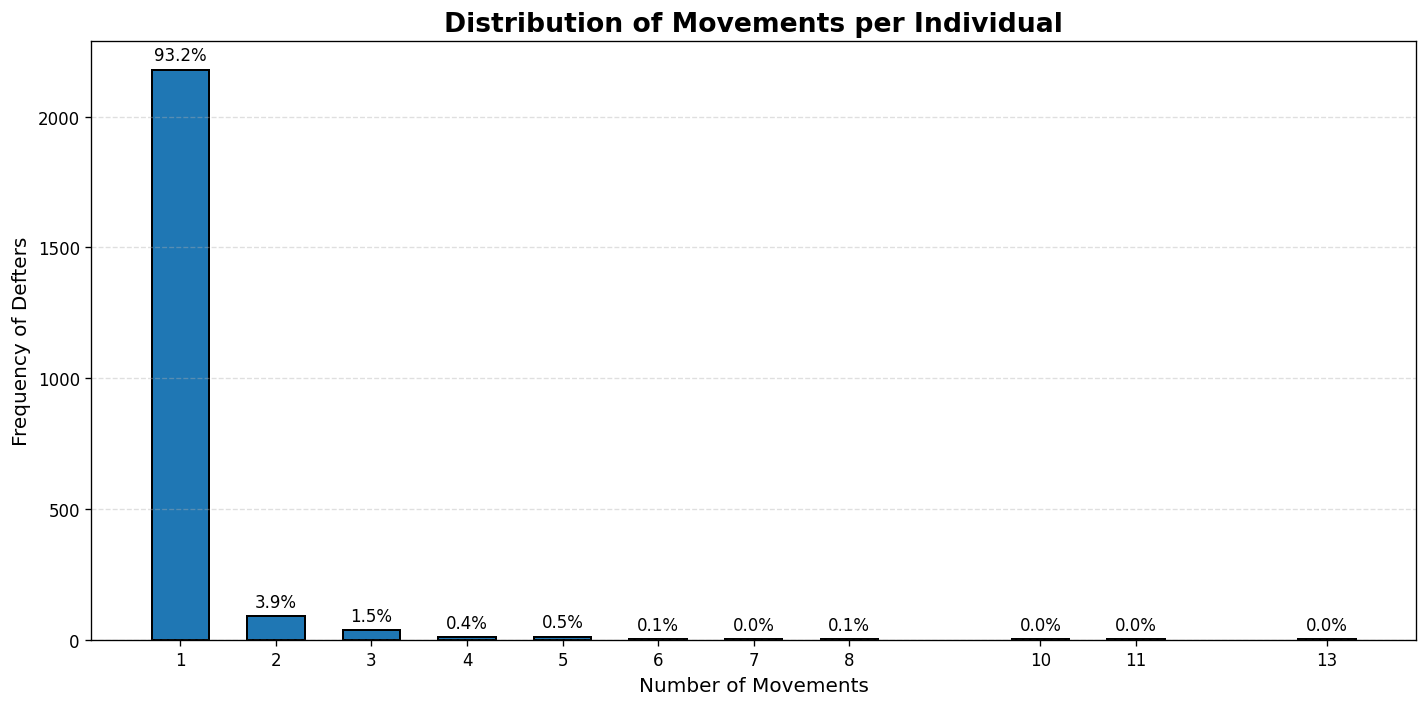

In [10]:
# ---- Histogram ----
value_counts = df_moves["n_moves"].value_counts().sort_index()
steps = value_counts.index.values
counts = value_counts.values
total_individuals = df_moves.shape[0]

plt.figure(figsize=(12, 6), dpi=120)

bars = plt.bar(steps, counts, width=0.6, edgecolor='black', linewidth=1.2)

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.xlabel("Number of Movements", fontsize=12)
plt.ylabel("Frequency of Defters", fontsize=12)
plt.title("Distribution of Movements per Individual", fontsize=16, fontweight='bold')

for bar, count in zip(bars, counts):
    height = bar.get_height()
    pct = count / total_individuals * 100 if total_individuals > 0 else 0.0
    plt.text(bar.get_x() + bar.get_width()/2,
             height + 20,
             f"{pct:.1f}%",
             ha='center', va='bottom', fontsize=10)

plt.xticks(steps)
plt.tight_layout()
plt.show()

In [11]:
# ============================================
# 1b) Place of origin distribution (Top 5)
# ============================================
origin_counts = df_moves["Place of origin"].value_counts(dropna=True)
total_origin = origin_counts.sum()

df_origin = pd.DataFrame({
    "Place of origin": origin_counts.index,
    "Count": origin_counts.values
})
df_origin["Pct"] = df_origin["Count"] / total_origin * 100

print("\n=== Top 5 Places of Origin ===")
display(df_origin.head(5))







=== Top 5 Places of Origin ===


,Place of origin,Count,Pct
0,Ohri,658,29.533214
1,Kalkandelen,285,12.791741
2,Asitane,234,10.502693
3,Manastır,181,8.123878
4,Prespe,63,2.827648


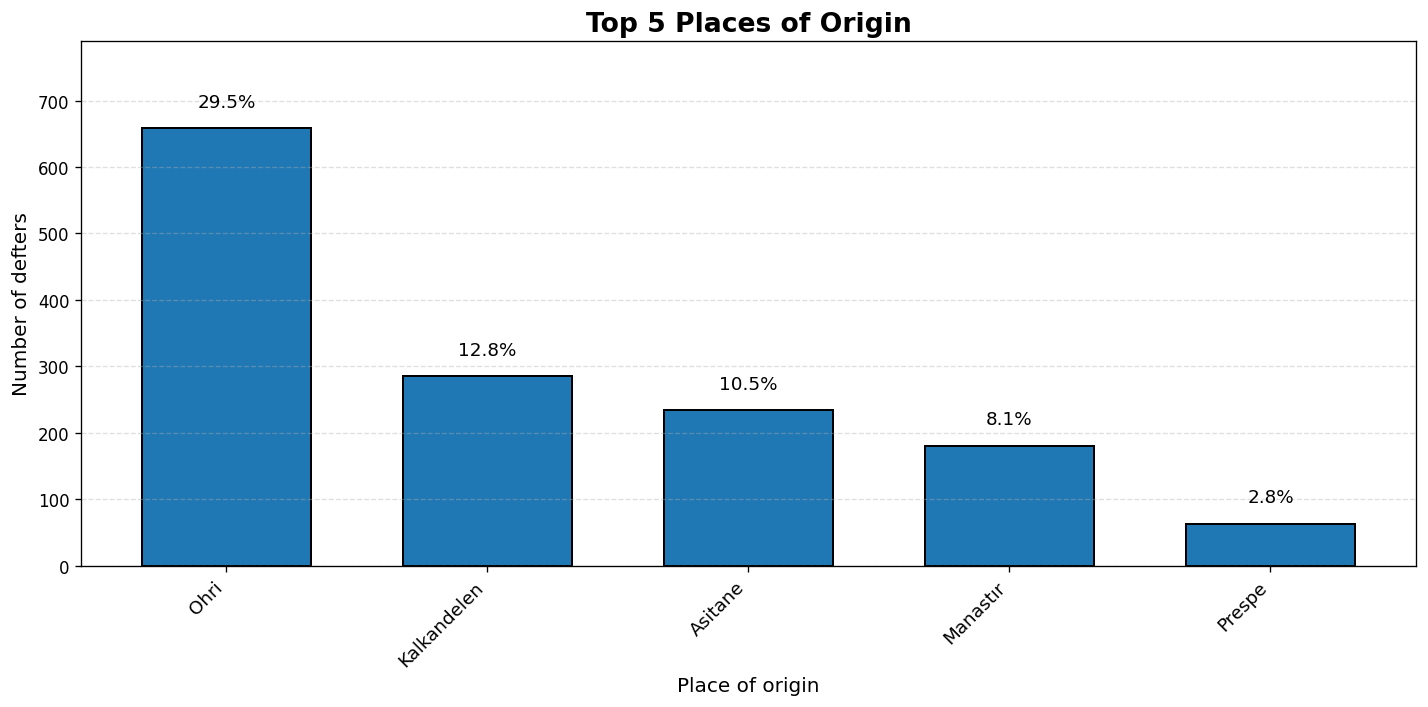

In [12]:
top_origin = df_origin.head(5)

plt.figure(figsize=(12, 6), dpi=120)
bars = plt.bar(top_origin["Place of origin"].astype(str),
               top_origin["Count"],
               width=0.65,
               edgecolor='black',
               linewidth=1.2)

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.xlabel("Place of origin", fontsize=12)
plt.ylabel("Number of defters", fontsize=12)
plt.title("Top 5 Places of Origin", fontsize=16, fontweight='bold')

plt.xticks(rotation=45, ha="right", fontsize=11)

max_count = top_origin["Count"].max()
offset = max_count * 0.04
plt.ylim(0, max_count * 1.20)

for bar, (_, row) in zip(bars, top_origin.iterrows()):
    height = bar.get_height()
    pct = row["Pct"]
    plt.text(bar.get_x() + bar.get_width()/2,
             height + offset,
             f"{pct:.1f}%",
             ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

In [14]:
# ============================================
# 2) destination frequencies
# ============================================
step_freq_list = []

for col in movement_cols: 
    vc = df_moves[col].value_counts(dropna=True)
    total = vc.sum()
    for place, count in vc.items():
        step_freq_list.append({
            "Step": col,
            "Place": place,
            "Count": count,
            "Pct": count / total * 100 if total > 0 else 0.0
        })

df_step_freq = pd.DataFrame(step_freq_list)

print("\n=== Top Destinations per Step ===")
display(df_step_freq.sort_values(["Step", "Count"], ascending=[True, False]).head(30))




=== Top Destinations per Step ===


,Step,Place,Count,Pct
281,location_10,Gelibolu,1,33.333333
282,location_10,Silivri,1,33.333333
283,location_10,İZmir,1,33.333333
284,location_11,Tatavla,3,100.000000
285,location_12,Silivri,1,50.000000
286,location_12,Kalas,1,50.000000
287,location_13,Tatavla,1,100.000000
288,location_14,Bursa,1,100.000000
0,location_2,Ohri,652,27.875160
1,location_2,Kalkandelen,286,12.227448


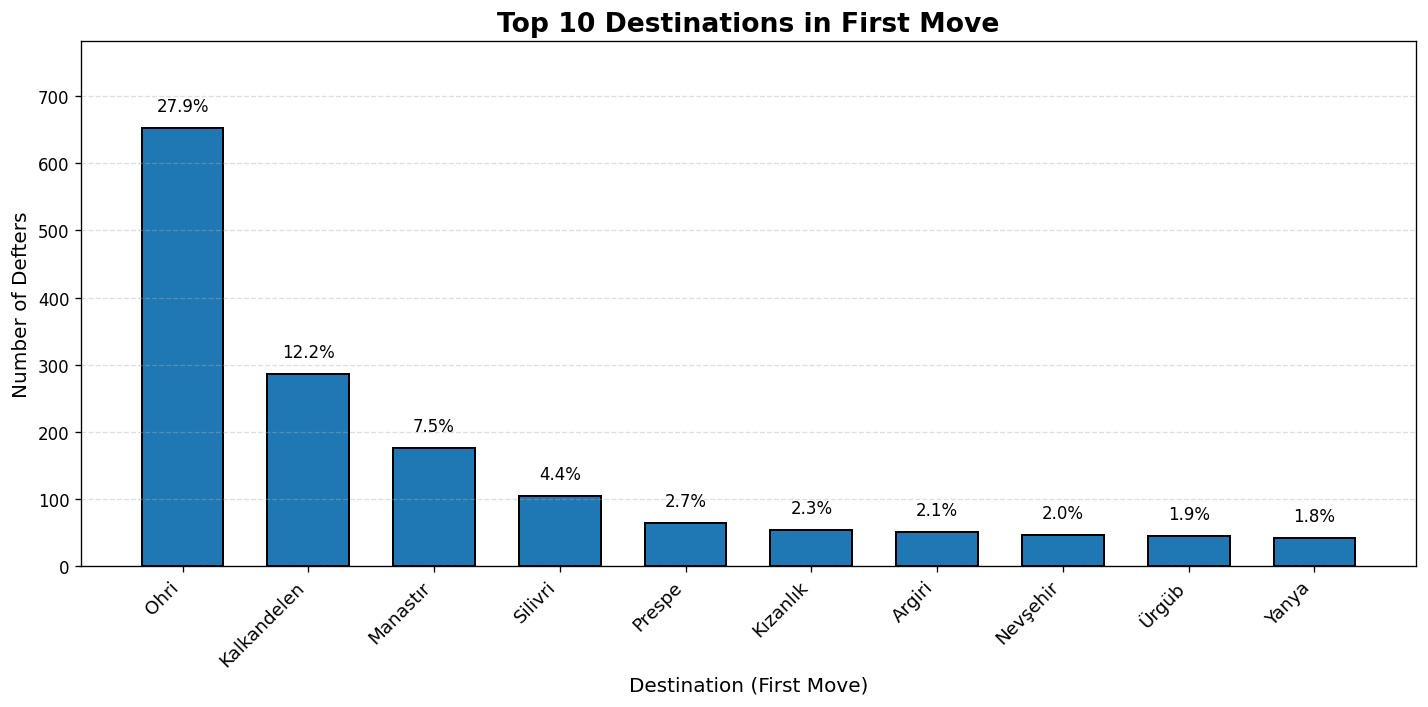

In [15]:
if "location_2" in movement_cols:
    top_loc2 = (
        df_step_freq[df_step_freq["Step"] == "location_2"]
        .sort_values("Count", ascending=False)
        .head(10)
    )

    total_first_moves = df_step_freq[df_step_freq["Step"] == "location_2"]["Count"].sum()

    plt.figure(figsize=(12, 6), dpi=120)
    bars = plt.bar(top_loc2["Place"].astype(str),
                   top_loc2["Count"],
                   width=0.65,
                   edgecolor='black',
                   linewidth=1.2)

    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.xlabel("Destination (First Move)", fontsize=12)
    plt.ylabel("Number of Defters", fontsize=12)
    plt.title("Top 10 Destinations in First Move",
              fontsize=16, fontweight='bold')

    plt.xticks(rotation=45, ha="right", fontsize=11)

    max_count = top_loc2["Count"].max()
    offset = max_count * 0.03
    plt.ylim(0, max_count * 1.20)

    for bar, (_, row) in zip(bars, top_loc2.iterrows()):
        height = bar.get_height()
        pct = row["Count"] / total_first_moves * 100 if total_first_moves > 0 else 0.0
        plt.text(bar.get_x() + bar.get_width()/2,
                 height + offset,
                 f"{pct:.1f}%",
                 ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.show()

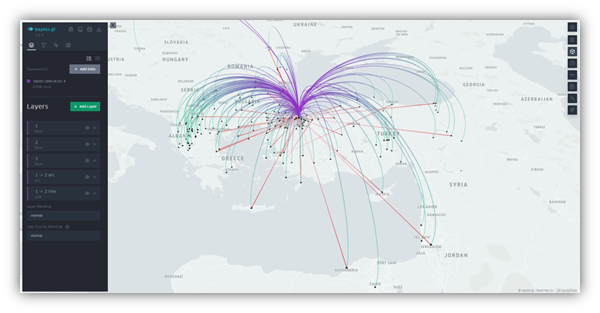

In [16]:
from IPython.display import Image, display

display(Image("./media/kepler_tatavla.png"))

### Fener

Descriptive statistics for the Fener dataset show similarly constrained levels of mobility as observed in Tatavla. 70.8% of individuals made only one recorded migration (Figure 6), and fewer than 5% moved three times or more. This suggests that, as in Tatavla, most people went to their place of origin and did not return.

The analysis of first migration reveals a pattern distinct from that of Tatavla. While Balkan destinations remain present, migrations from Fener demonstrate a more distributed geographic footprint. The top destinations in the first movement include Izmir (4.7%), Silivri (4.5%), Bursa (4.0%), and Aynaroz (3.7%) (Figure 7). This regional diversity suggests a wider set of networks and mobility motivations among the residents of Fener—spanning western Anatolia, Thrace, and the Aegean.

A look at reported places of origin reinforces the above interpretation. The most common origins include Asitane (30.9%), Şarköy (4.4%), and Yanya (3.3%) (Figure 8). Unlike Tatavla—where places of origin are closely aligned with the most frequent first destinations—Fener shows weaker overlap between where individuals came from and where they moved first, suggesting different mobility dynamics. This pattern is corroborated by the return summary: only 25.3% of individuals ever reached their place of origin. These figures stand in stark contrast to the predominantly circular mobility observed in Tatavla. Moreover, no individuals in the dataset returned to Fener after departure, indicating that movements originating in this neighborhood were less likely to be cyclical and more indicative of ongoing, outward migration rather than temporary movements followed by returns.

Spatial visualization further shows the results. Figure 9 illustrates outbound movement spreading from Fener in multiple directions across the eastern Mediterranean, including Cyprus, the Levant, and western Anatolia, alongside Balkan destinations familiar from the Tatavla dataset. As with Tatavla, each line may represent multiple individuals following similar trajectories; thus, cross-referencing with statistical distribution is necessary to fully interpret route prominence. Overall, the visualization highlights a less circular and more multi-destination mobility pattern for Fener, one in which Istanbul served not only as a point of temporary settlement but also as a transit node linking diverse regions of the Ottoman Empire.

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import re
import numpy as np

# ============================================
# 0) Load cleaned movement data
# ============================================
sheet_full = "Full Data Fener"

df_full = pd.read_excel(file_with_context, sheet_name=sheet_full)

df_moves = df_full[df_full["Formatting Evaluation"] == 1].copy()

print(f"Total records in sheet: {len(df_full)}")
print(f"Records after filtering Formatting Evaluation == 1: {len(df_moves)}")

location_cols = [c for c in df_moves.columns 
                 if re.fullmatch(r"location_\d+", c)]

location_cols = sorted(location_cols, key=lambda x: int(x.split("_")[1]))

print("\nMovement columns considered (clean):")
print(location_cols)

# --------------------------------------------
# Normalize location names (merge X / Xli + case)
# --------------------------------------------
def normalize_location_name(x):
    if pd.isna(x):
        return x
    if not isinstance(x, str):
        return x
    s = x.strip()
    s_lower = s.lower()

    if s_lower.endswith("li") and len(s_lower) > 3:
        s_lower = s_lower[:-2].strip()

    return s_lower.title()

cols_to_normalize = ["Place of origin"] + location_cols
for col in cols_to_normalize:
    if col in df_moves.columns:
        df_moves[col] = df_moves[col].apply(normalize_location_name)

movement_cols = location_cols[1:]






Total records in sheet: 417
Records after filtering Formatting Evaluation == 1: 404

Movement columns considered (clean):
['location_1', 'location_2', 'location_3', 'location_4', 'location_5', 'location_6', 'location_7', 'location_8', 'location_9', 'location_10', 'location_11']


In [18]:
# ============================================
# 1) Number of moves per person
# ============================================
df_moves["n_moves"] = df_moves[movement_cols].notna().sum(axis=1)

print("\n=== Movement Count Statistics per Person (excluding starting point) ===")
display(df_moves["n_moves"].describe().to_frame(name="Movement Count Stats"))




=== Movement Count Statistics per Person (excluding starting point) ===


,Movement Count Stats
count,404.000000
mean,1.564356
std,1.106407
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,10.000000


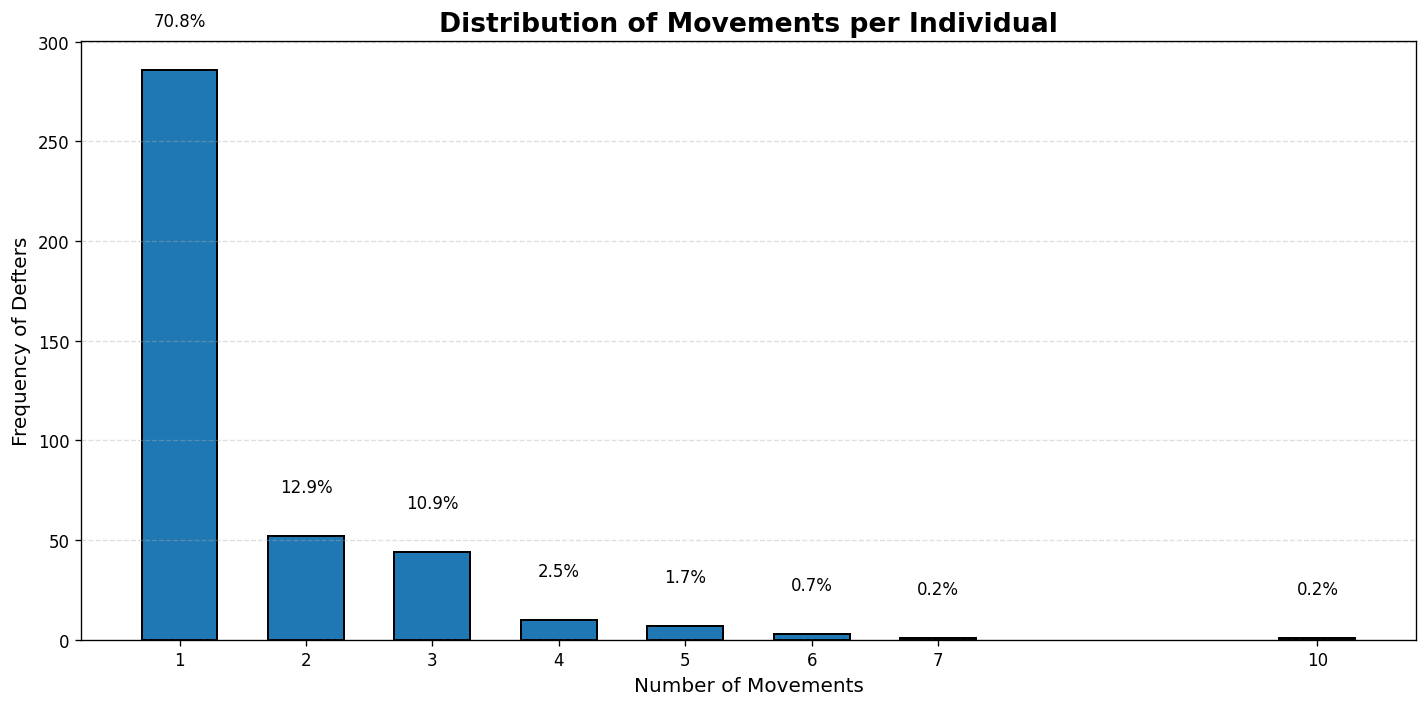

In [19]:
# ---- Histogram ----
value_counts = df_moves["n_moves"].value_counts().sort_index()
steps = value_counts.index.values
counts = value_counts.values
total_individuals = df_moves.shape[0]

plt.figure(figsize=(12, 6), dpi=120)

bars = plt.bar(steps, counts, width=0.6, edgecolor='black', linewidth=1.2)

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.xlabel("Number of Movements", fontsize=12)
plt.ylabel("Frequency of Defters", fontsize=12)
plt.title("Distribution of Movements per Individual", fontsize=16, fontweight='bold')

for bar, count in zip(bars, counts):
    height = bar.get_height()
    pct = count / total_individuals * 100 if total_individuals > 0 else 0.0
    plt.text(bar.get_x() + bar.get_width()/2,
             height + 20,
             f"{pct:.1f}%",
             ha='center', va='bottom', fontsize=10)

plt.xticks(steps)
plt.tight_layout()
plt.show()

In [20]:

# ============================================
# 1b) Place of origin distribution (Top 5)
# ============================================
origin_counts = df_moves["Place of origin"].value_counts(dropna=True)
total_origin = origin_counts.sum()

df_origin = pd.DataFrame({
    "Place of origin": origin_counts.index,
    "Count": origin_counts.values
})
df_origin["Pct"] = df_origin["Count"] / total_origin * 100

print("\n=== Top 5 Places of Origin ===")
display(df_origin.head(5))




=== Top 5 Places of Origin ===


,Place of origin,Count,Pct
0,Asitane,113,30.874317
1,Şarköy,16,4.371585
2,Yanya,12,3.278689
3,Midil,8,2.185792
4,Trabzon,8,2.185792


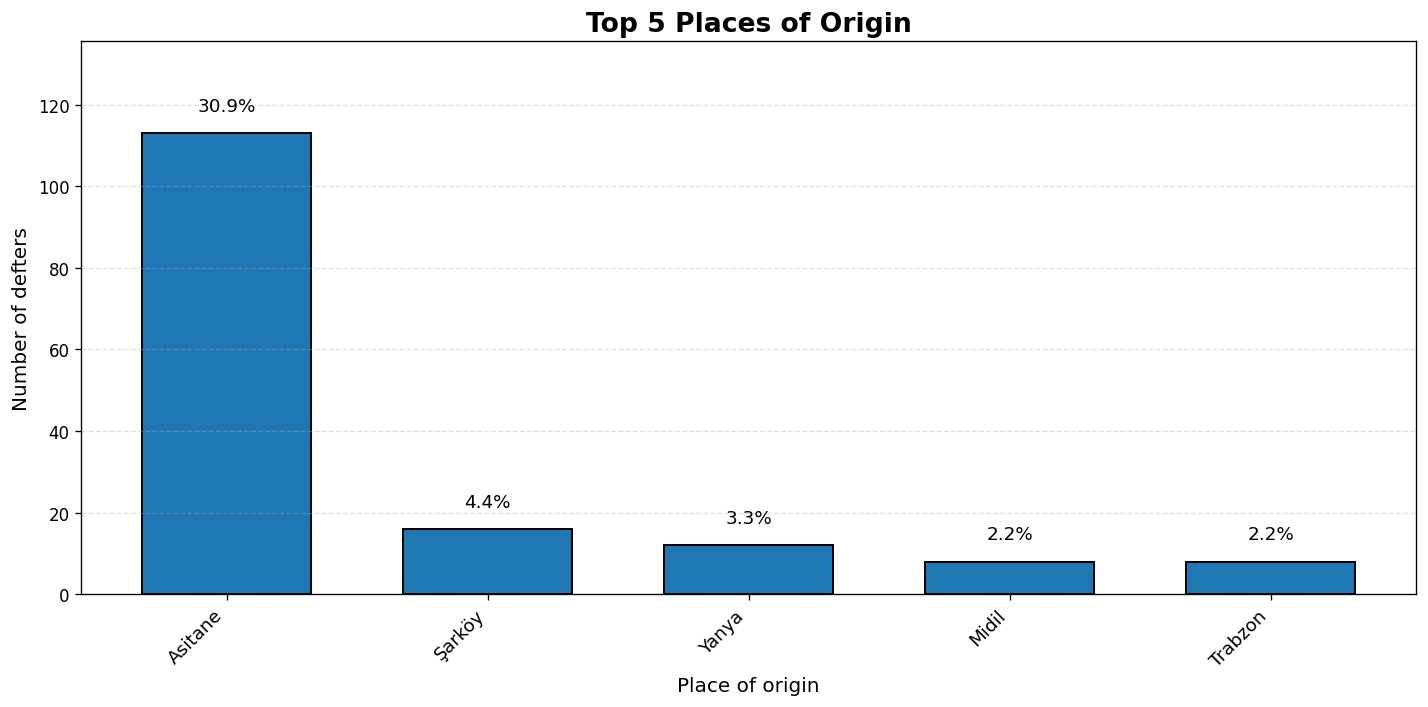

In [21]:
top_origin = df_origin.head(5)

plt.figure(figsize=(12, 6), dpi=120)
bars = plt.bar(top_origin["Place of origin"].astype(str),
               top_origin["Count"],
               width=0.65,
               edgecolor='black',
               linewidth=1.2)

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.xlabel("Place of origin", fontsize=12)
plt.ylabel("Number of defters", fontsize=12)
plt.title("Top 5 Places of Origin", fontsize=16, fontweight='bold')

plt.xticks(rotation=45, ha="right", fontsize=11)

max_count = top_origin["Count"].max()
offset = max_count * 0.04
plt.ylim(0, max_count * 1.20)

for bar, (_, row) in zip(bars, top_origin.iterrows()):
    height = bar.get_height()
    pct = row["Pct"]
    plt.text(bar.get_x() + bar.get_width()/2,
             height + offset,
             f"{pct:.1f}%",
             ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

In [22]:
# ============================================
# 2) destination frequencies
# ============================================
step_freq_list = []

for col in movement_cols:  # start from location_2
    vc = df_moves[col].value_counts(dropna=True)
    total = vc.sum()
    for place, count in vc.items():
        step_freq_list.append({
            "Step": col,
            "Place": place,
            "Count": count,
            "Pct": count / total * 100 if total > 0 else 0.0
        })

df_step_freq = pd.DataFrame(step_freq_list)

print("\n=== Top Destinations per Step ===")
display(df_step_freq.sort_values(["Step", "Count"], ascending=[True, False]).head(30))



=== Top Destinations per Step ===


,Step,Place,Count,Pct
221,location_10,Adapazarı,1,100.000000
222,location_11,Fener,1,100.000000
0,location_2,Izmir,19,4.702970
1,location_2,Silivri,18,4.455446
2,location_2,Bursa,16,3.960396
3,location_2,Aynaroz,15,3.712871
4,location_2,Kuds,14,3.465347
5,location_2,Tekfurdağı,13,3.217822
6,location_2,Şarköy,12,2.970297
7,location_2,Edirne,11,2.722772


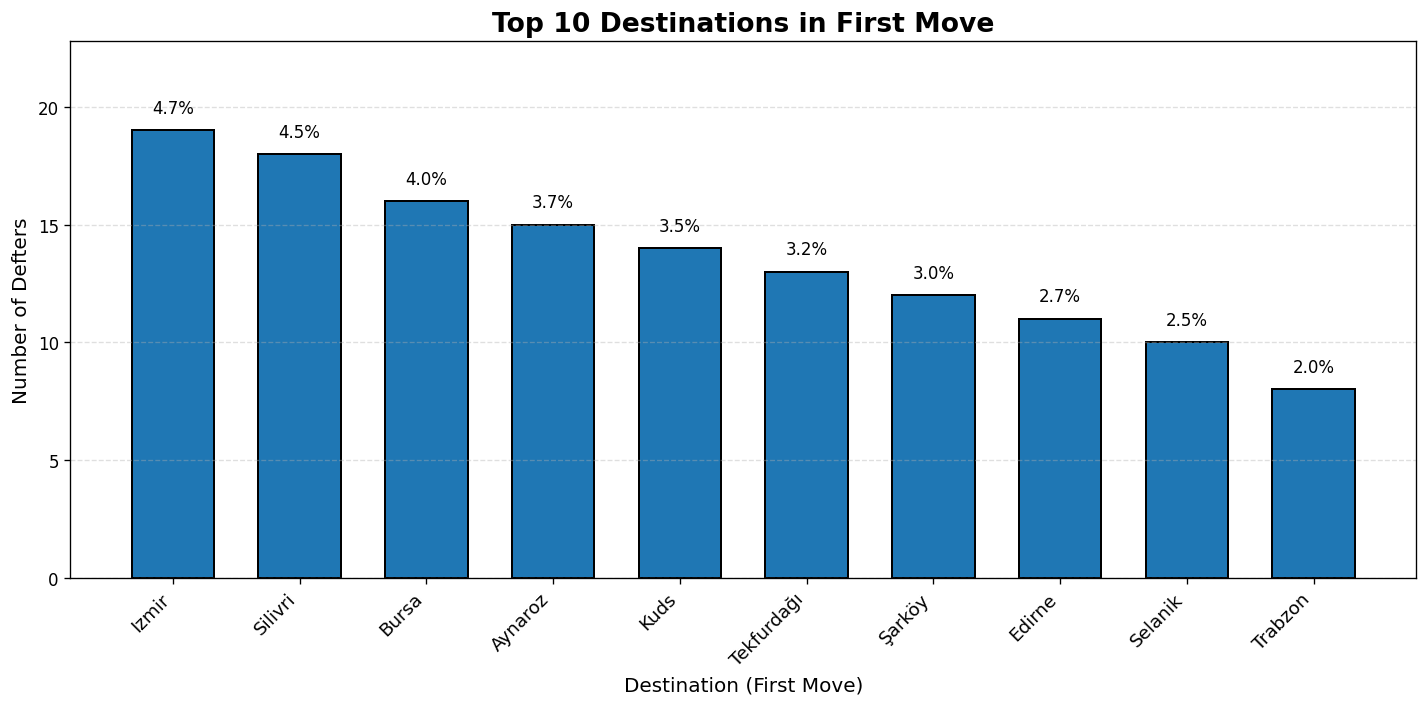

In [23]:

if "location_2" in movement_cols:
    top_loc2 = (
        df_step_freq[df_step_freq["Step"] == "location_2"]
        .sort_values("Count", ascending=False)
        .head(10)
    )

    total_first_moves = df_step_freq[df_step_freq["Step"] == "location_2"]["Count"].sum()

    plt.figure(figsize=(12, 6), dpi=120)
    bars = plt.bar(top_loc2["Place"].astype(str),
                   top_loc2["Count"],
                   width=0.65,
                   edgecolor='black',
                   linewidth=1.2)

    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.xlabel("Destination (First Move)", fontsize=12)
    plt.ylabel("Number of Defters", fontsize=12)
    plt.title("Top 10 Destinations in First Move",
              fontsize=16, fontweight='bold')

    plt.xticks(rotation=45, ha="right", fontsize=11)

    max_count = top_loc2["Count"].max()
    offset = max_count * 0.03
    plt.ylim(0, max_count * 1.20)

    # Labels above bars (PERCENTAGES)
    for bar, (_, row) in zip(bars, top_loc2.iterrows()):
        height = bar.get_height()
        pct = row["Count"] / total_first_moves * 100 if total_first_moves > 0 else 0.0
        plt.text(bar.get_x() + bar.get_width()/2,
                 height + offset,
                 f"{pct:.1f}%",
                 ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.show()


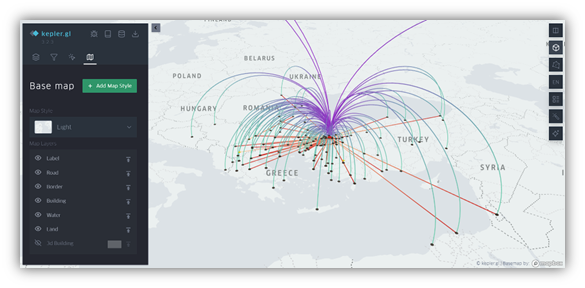

In [24]:
from IPython.display import Image, display

display(Image("./media/kepler_fener.png"))

Reflecting on the results, the contrasting mobility patterns observed in Tatavla and Fener can be better understood when the different historical and socioeconomic profiles of the two neighborhoods are considered. Tatavla developed as a predominantly Greek Orthodox district with strong connections to working-class and migrant populations. Historical accounts trace part of its early Greek population to sailors and other maritime workers who had been brought to work in the Kasımpaşa shipyards and who later settled in Tatavla after gaining their freedom. The neighborhood also received migrants from places such as Chios and the Peloponnese, including both workers and merchants <cite id="man4"><a href="#akaki2023">(Akaki 2023)</a></cite>. More broadly, research on the Greek Orthodox population of nineteenth-century Istanbul shows that a substantial share of the community consisted of migrants and their descendants from rural areas outside the capital <cite id="man5"><a href="#anastassiadou2009">(Anastassiadou 2009)</a></cite>.

The above characteristic of migration in Tatavla also provides a plausible historical context for the strong overlap observed in our data between places of origin and first migration destinations. Rather than indicating mobility across a wide range of unrelated destinations, many of the movements recorded from Tatavla appear to correspond to returns toward places from which residents or their families had previously migrated. Thus, Tatavla may have functioned for part of its recorded population as a temporary urban destination connected to labor and economic opportunities in Istanbul while individuals maintained strong ties to their hometowns and regions of origin.

On the other hand, Fener occupied a markedly different position within Istanbul’s Greek Orthodox community. The neighborhood was the seat of the Ecumenical Patriarchate and became closely associated with the Phanariots, influential Greek Orthodox families involved in commerce, ecclesiastical administration, diplomacy, and Ottoman governance. Historical research describes the transformation of Fener from an earlier waterfront settlement into a center of an increasingly wealthy Orthodox mercantile and political elite, including families connected to the administration of Wallachia and Moldavia <cite id="man6"><a href="#erkalsumertas2022">(Erkal and Sümertaş 2022)</a></cite>. Phanariot families held important positions such as dragomans of the Porte and the Fleet and, during the eighteenth and early nineteenth centuries, served as rulers of Wallachia and Moldavia, creating political, ecclesiastical, commercial, and diplomatic networks extending far beyond Istanbul. Fener was therefore embedded in a broader set of institutional and geographic connections than those associated with a predominantly labor-oriented neighborhood such as Tatavla. This historical context may help explain why the Fener records show a more geographically dispersed pattern of movement across western Anatolia, Thrace, the Aegean, the Balkans, and other parts of the Ottoman Empire rather than the strong origin-return pattern visible in Tatavla.

These interpretations should nevertheless be treated cautiously. The observed patterns do not demonstrate that neighborhood socioeconomic composition directly caused individual migration decisions. Instead, the historical differences between Tatavla and Fener provide a plausible context for interpreting why the two datasets display distinct mobility structures. Moreover, as mentioned before, the patterns reflect the populations and movements made visible by the original census-registration practices rather than the totality of mobility experienced by residents of either neighborhood.

## Discussion

Our study demonstrates that LLMs can support and accelerate historical research on complex, transliterated archival sources such as Ottoman defters. Rather than proposing an entirely new computational workflow, our approach builds on established practices in data processing, software evaluation, validation, and human-in-the-loop verification, introducing an LLM as a flexible component for tasks that have traditionally required extensive manual interpretation. The methodological contribution therefore lies not in replacing established computational practices, but in examining where an LLM can be integrated into them, where it provides measurable advantages, and where conventional tools and expert validation remain necessary. 

Within this context, our findings contribute both to digital humanities and the study of Ottoman population registers. Regarding data extraction, formatting, and geolocation, GPT-4o demonstrates a notable capacity to interpret migration strings, recognize place names (including historically attested or obsolete toponyms), and convert them into structured outputs suitable for analytical use when provided with context and a strict set of rules. In many instances, the model succeeded where modern geolocation tools struggled, particularly when handling outdated or ambiguous place names. This advantage appears to stem from the model’s broader linguistic exposure and ability to leverage contextual cues. However, the model still exhibits knowledge gaps that require intervention.

Variations in spelling or suffixes within transliterated sources remain a persistent challenge, even for GPT-4o, and likely for any other LLM. Normalization of historical toponyms therefore continues to be a critical issue to address in future work. It is necessary to develop strategies that can manage variation while also reducing the number of input tokens required. We argue that simply expanding prompts with additional contextual information is not a scalable solution, as it increases token usage and becomes impractical given the large number of possible orthographic variants in Ottoman sources.

A promising direction is to augment LLMs with external knowledge sources that may not be represented in their training data, while also exploring richer semantic layers that support automatic representation, retrieval, and reuse. Similar approaches have already been investigated in modeling and simulation, where semantic representations and retrieval strategies are used to support the discovery, comparison, and reuse of existing models (<cite id="pkzas"><a href="#zotero%7C21909901%2FKB2MB5C6">(Martínez et al. 2024)</a></cite>, <cite id="p8t0n"><a href="#zotero%7C21909901%2FZYX4KJZG">(Botello et al. 2025)</a></cite>, <cite id="man7"><a href="#botelloetal2026">(Botello et al. 2026)</a></cite>). Extending these ideas to Digital History could enable LLM-based systems to incorporate domain-specific historical resources, construct more structured representations of archival knowledge, and better support the retrieval and reuse of historical information. For example, fine-tuning with historically specific datasets may improve the model’s understanding of toponyms and documentary conventions, although it remains computationally expensive and requires extensive data curation. Another complementary solution is the incorporation of Retrieval-Augmented Generation (RAG), in which the model queries external databases during inference to verify, refine, or correct extracted information. Such an approach would enable the model to resolve spelling variation, identify place names more accurately, and assign historically informed coordinates without relying solely on its pre-trained knowledge.

Additionally, every LLM output should not be viewed as a one-off inference, but rather as a data artifact worth preserving. Storing and indexing resolved place names and coordinates in a structured knowledge base would prevent redundant model queries for information that the LLM has already generated. Over time, such a growing repository of validated outputs could serve as a training or retrieval resource for lighter-weight models, substantially reducing computational load and enabling more scalable, cost-efficient workflows for historical data processing. In another case, rather than relying on an LLM to repeatedly infer the same place, researchers could consult a previously validated database and retrieve the corresponding coordinates directly, avoiding unnecessary inference.

Another key practical implication of our approach lies in the potential to integrate LLM-processed defter data into semantic databases such as FactGrid, a collaborative Wikibase designed for historical research. Because our workflow outputs highly structured JSON that maps naturally onto item–property relationships, it can be used to populate knowledge graphs with information about individuals, households, occupations, places of origin, and migratory movements. Once integrated into FactGrid, these data can support advanced querying, connect defter-derived information to external geographic reference sources and standardized name lists, and enable interoperability across projects in Ottoman studies and beyond. This, in turn, enhances the visibility and reusability of defter-based research while providing an open foundation for subsequent demographic, spatial, and network analyses. Future work could also combine RAG with the FactGrid knowledge graph (and knowledge embedding) as a method for entity linking with LLM reasoning.

Looking further ahead, AI components could be orchestrated within agentic AI workflows that manage end-to-end pipelines rather than isolated tasks. Such a system could automatically process new defter material by chaining together handwritten text recognition (HTR), transliteration, digitization, data formatting, geolocation, date conversion, human-in-the-loop validation, semantic enrichment, and ingestion into platforms such as FactGrid, which support GeoJSON,<sup><a href="#fn8" id="ref8">8</a></sup> or Geographic Information Systems (GIS) environments. While developing fully automated pipelines of this kind is far from trivial, advancing toward them should be a central topic in interdisciplinary collaborations between historians, Computer scientists, and digital humanists. Rather than replacing historians, an agentic workflow would allow them to intervene at critical decision and evaluation points—reviewing uncertain cases, adjusting constraints, or refining prompts—while delegating repetitive preprocessing steps to AI. Such systems would make it feasible to scale analyses from individual notebooks to entire corpora of defters and comparable archival materials. However, human-in-the-loop approaches also introduce methodological considerations, as human judgments may be influenced by model suggestions and can introduce variability into the evaluation process <cite id="man8"><a href="#schroederetal2025">(Schroeder et al. 2025)</a></cite>. This further highlights the importance of clearly defined evaluation and intervention criteria for human-in-the-loop strategies. In our experiments, the expert did not have access to any LLM output when constructing the ground truth, reducing the risk of bias from model suggestions.

<hr>

<ol start="8">
  <li id="fn8"><a href="https://en.wikipedia.org/wiki/GeoJSON">https://en.wikipedia.org/wiki/GeoJSON</a>
      <a href="#ref8"></a>
  </li>
</ol>

On the other hand, the uneven performance observed in date conversion underscores the need for additional forms of intervention. While GPT-4o accurately converted years, accuracy declined significantly when handling month- and day-level information, particularly in the presence of Ottoman Turkish abbreviations. This discrepancy likely reflects both the limited representation of such patterns in the model’s training data and the inherent ambiguity of the sources themselves. However, it is important to note that challenges related to temporal expressions extend beyond LLMs. The difficulty observed with incomplete and abbreviated date strings is consistent with broader work on temporal normalization, which has shown that ambiguous or imprecise temporal expressions, especially those represented across different calendar systems, are difficult to map reliably to standardized temporal representations (<cite id="man10"><a href="#tissotetal2019">(Tissot et al. 2019)</a></cite>, <cite id="man9"><a href="#bindingtudhope2023">(Binding and Tudhope 2023)</a></cite>). This suggests that date conversion is inherently challenging even before LLMs are introduced and that hybrid strategies may be necessary. Addressing these challenges will require moving toward AI agents capable of coordinating language-model inference with domain-specific resources, such as curated Hijri→Gregorian conversion tables, calendar alignment rules, and expert-validated reference data. Such agentic systems could detect uncertainty in model predictions and seek external evidence to resolve it, improving temporal precision and preserving historical accuracy.

Overall, our results show that LLMs are powerful but still imperfect tools. However, by automating much of the tedious preprocessing work, they free historians to focus on interpretation, contextualization, and critique—the core of historiographical practice. At the same time, AI-assisted workflows encourage new forms of collaboration between historians, computer scientists, and digital humanists, fostering interdisciplinary experimentation with methods that combine archival rigor with computational sophistication. As models, retrieval pipelines, and agentic systems continue to evolve, we anticipate that workflows and systems like the one presented and discussed here will become an important bridge between traditional, document-centered scholarship and large-scale, data-driven reconstructions of the past.

## Limitations

We highlight several limitations. First, LLMs are inherently non-deterministic; even with temperature set to zero and outputs constrained through JSON schemas, small variations may arise when reproducing our work. Second, the model’s performance remains contingent on its training data; it performs best when it can rely on familiar linguistic and geographical patterns. Additionally, the model is more likely to fail for highly domain-specific abbreviations, requiring extensive prompt engineering. However, abbreviations could be mitigated by using FactGrid’s triple store for collecting aliases under the same label and identifier. Third, the challenges posed by incomplete or ambiguous date strings—particularly those that only partially specify day, month, or year—likely remain only partially addressed by our current prompt. Finally, our evaluation focuses on a single proprietary model (GPT-4o). While the workflow is conceptually replicable with open-source models, realizing this in practice would require additional engineering to support structured output, batch processing, and potentially different API conventions, as specified in the methodology section.

## Conclusion

In this study, we demonstrated that LLMs can meaningfully support the reconstruction of migratory movements from Ottoman census registers by automating key preprocessing tasks that have traditionally required extensive manual labor, including data extraction, historical toponym resolution, and partial Hijri to Gregorian date conversion. While GPT-4o showed promising performance—particularly in identifying historical places and extracting chronological sequences—its limitations in month- and day-level date conversion and its dependence on ambiguous transliterations highlight the continued need for expert guidance and critical oversight. By producing structured, interoperable datasets suitable for integration into platforms such as FactGrid, our workflow offers a practical pathway for scaling historical analyses of defters and similar archival materials. More broadly, this work illustrates how AI-assisted methods can augment, rather than replace, human expertise, opening opportunities for future research involving fine-tuned models, retrieval-augmented systems, and agentic AI pipelines capable of supporting richer and more expansive forms of digital historiography. 

Regarding the analysis of movements, we were able to analyze and visualize movements of the Greek Orthodox community located in Tatavla and Fener. Tatavla primarily functioned as a temporary urban hub: most individuals migrated only once and ultimately returned to their places of origin in the Balkans. By contrast, residents of Fener moved to more geographically dispersed destinations and were far less likely to return home, suggesting broader regional networks and more permanent mobility patterns.


## References

<!-- BIBLIOGRAPHY START -->
<div class="csl-bib-body">
  <div class="csl-entry"><i id="akaki2023"></i>Akaki, Y. 2023. “Kurtuluş/ταταύλα.” <i>İstanΠόλις</i>, July 17, 2023. <a href="https://www.istanpolis.org/post/kurtulu%C5%9F-the-working-class-heart-of-istanbul">https://www.istanpolis.org/post/kurtulu%C5%9F-the-working-class-heart-of-istanbul</a>.</div>
  <div class="csl-entry"><i id="anastassiadou2009"></i>Anastassiadou, Meropi. 2009. “Greek Orthodox Immigrants and Modes of Integration within the Urban Society of Istanbul (1850–1923).” <i>Mediterranean Historical Review</i> 24 (2): 151–167.</div>
  <div class="csl-entry"><i id="zotero|21909901/ZP649KDV"></i>Behar, Cem. 2011. “Osmanlı İmparatorluğu’nun ve Türkiye’nin Nüfusu 1500-1927 = the Population of the Ottoman Empire and Turkey 1500-1927.” <i>Ankara : Başbakanlık, Devlet İstatistik Enstitüsü (DİE)</i>. <a href="https://kutuphane.tarimorman.gov.tr/vufind/Record/1251966">https://kutuphane.tarimorman.gov.tr/vufind/Record/1251966</a>.</div>
  <div class="csl-entry"><i id="bindingtudhope2023"></i>Binding, Ceri, and Douglas Tudhope. 2023. “Automatic Normalization of Temporal Expressions.” <i>Journal of Computer Applications in Archaeology</i> 6 (1): 24–39.</div>
  <div class="csl-entry"><i id="zotero|21909901/ZL8ZUR3D"></i>Botello, Jhon G., Lesley Frew, Jose J. Padilla, and Michele C. Weigle. 2024. “Exploring Large Language Models for Analyzing Changes in Web Archive Content: A Retrieval-Augmented Generation Approach.” In <i>2024 IEEE International Conference on Big Data (BigData)</i>, 2410–18. Washington, DC, USA: IEEE. <a href="https://doi.org/10.1109/BigData62323.2024.10826069">https://doi.org/10.1109/BigData62323.2024.10826069</a>.</div>
  <div class="csl-entry"><i id="zotero|21909901/ZYX4KJZG"></i>Botello, Jhon G., Brian Llinas, Jose J. Padilla, and Erika Frydenlund. 2025. “Toward Automating System Dynamics Modeling: Evaluating LLMs in the Transition from Narratives to Formal Structures.” In <i>2025 Winter Simulation Conference (WSC)</i>. Seattle, WA, USA: IEEE.</div>
  <div class="csl-entry"><i id="botelloetal2026"></i>Botello, Jhon G., Jose J. Padilla, Erika Frydenlund, K. Rechowicz, and E. Weisel. 2026. “How Can AI Find My Model? A Model-Finding Experimental Study Considering Data Formats, Embeddings, and Retrieval Strategies.” <i>arXiv preprint</i> arXiv:2606.30846. <a href="https://arxiv.org/abs/2606.30846">https://arxiv.org/abs/2606.30846</a>.</div>
  <div class="csl-entry"><i id="zotero|21909901/4JVXJISK"></i>Celli, Fabio, and Georgios Spathulas. 2025. “Language Models Reach Higher Agreement than Humans in Historical Interpretation.” arXiv. <a href="https://doi.org/10.48550/ARXIV.2504.02572">https://doi.org/10.48550/ARXIV.2504.02572</a>.</div>
  <div class="csl-entry"><i id="zotero|21909901/VBI3H6FK"></i>Cheng, Zhoujun, Jungo Kasai, and Tao Yu. 2023. “Batch Prompting: Efficient Inference with Large Language Model APIs.” arXiv. <a href="https://doi.org/10.48550/ARXIV.2301.08721">https://doi.org/10.48550/ARXIV.2301.08721</a>.</div>
  <div class="csl-entry"><i id="zotero|21909901/RVLSLD94"></i>Clavert, Frédéric, and Caroline Muller. 2024. “L’histoire Au Temps Des Algorithmes: Une Réflexion Prospective Sur l’introduction de l’intelligence Artificielle En Histoire Au 21 e Siècle.” <i>20 &#38; 21. Revue d’histoire</i> N° 162 (2): 13–26. <a href="https://doi.org/10.3917/vin.162.0013">https://doi.org/10.3917/vin.162.0013</a>.</div>
  <div class="csl-entry"><i id="zotero|21909901/UPKJMW38"></i>Coşgel, Metin M. 2004. “Ottoman Tax Registers ( <i>Tahrir Defterleri</i> ).” <i>Historical Methods: A Journal of Quantitative and Interdisciplinary History</i> 37 (2): 87–102. <a href="https://doi.org/10.3200/HMTS.37.2.87-102">https://doi.org/10.3200/HMTS.37.2.87-102</a>.</div>
  <div class="csl-entry"><i id="zotero|21909901/BFL9ACDI"></i>Ehrmann, Maud, Ahmed Hamdi, Elvys Linhares Pontes, Matteo Romanello, and Antoine Doucet. 2024. “Named Entity Recognition and Classification in Historical Documents: A Survey.” <i>ACM Computing Surveys</i> 56 (2): 1–47. <a href="https://doi.org/10.1145/3604931">https://doi.org/10.1145/3604931</a>.</div>
  <div class="csl-entry"><i id="erkalsumertas2022"></i>Erkal, Namık, and Firuzan Melike Sümertaş. 2022. “‘Of a Piece with Their Habitations’: Phanariots and Their Houses on the Phanar Waterfront.” <i>YILLIK: Annual of Istanbul Studies</i> 4: 7–44. <a href="https://doi.org/10.53979/yillik.2022.2">https://doi.org/10.53979/yillik.2022.2</a>.</div>
  <div class="csl-entry"><i id="erunal2021"></i>Erünal, Efe. 2021. “Examining Age Structure and Estimating Mortality Rates in Ottoman Bursa Using Mid-Nineteenth-Century Population Registers.”<i>Middle Eastern Studies</i> 57 (2): 179–196. <a href="https://doi.org/10.1080/00263206.2020.1844672">https://doi.org/10.1080/00263206.2020.1844672</a>.</div>
  <div class="csl-entry"><i id="faassenhoekstra2022"></i>Van Faassen, Marijke, and Rik Hoekstra. 2022. “Migrant Visibility: Digitization and Heritage Policies.” <i>Frontiers in Human Dynamics</i> 4: 908456. <a href="https://doi.org/10.3389/fhumd.2022.908456">https://doi.org/10.3389/fhumd.2022.908456</a>.</div>
  <div class="csl-entry"><i id="zotero|21909901/TDXGUXFN"></i>Garcia, Giselle Gonzalez, and Christian Weilbach. 2023. “If the Sources Could Talk: Evaluating Large Language Models for Research Assistance in History.” arXiv. <a href="https://doi.org/10.48550/ARXIV.2310.10808">https://doi.org/10.48550/ARXIV.2310.10808</a>.</div>
  <div class="csl-entry"><i id="zotero|21909901/WJ9NMMYC"></i>Giray, Louie. 2023. “Prompt Engineering with ChatGPT: A Guide for Academic Writers.” <i>Annals of Biomedical Engineering</i> 51 (12): 2629–33. <a href="https://doi.org/10.1007/s10439-023-03272-4">https://doi.org/10.1007/s10439-023-03272-4</a>.</div>
  <div class="csl-entry"><i id="zotero|21909901/8UY3X7H6"></i>Hiltmann, Torsten, Martin Dröge, Nicole Dresselhaus, Till Grallert, Melanie Althage, Paul Bayer, Sophie Eckenstaler, et al. 2025. “NER4all or Context Is All You Need: Using LLMs for Low-Effort, High-Performance NER on Historical Texts. A Humanities Informed Approach.” arXiv. <a href="https://doi.org/10.48550/ARXIV.2502.04351">https://doi.org/10.48550/ARXIV.2502.04351</a>.</div>
  <div class="csl-entry"><i id="zotero|21909901/VZEPVNV5"></i>Hutchinson, Daniel. 2022. “What Do AIs ‘Know’ About History? A Digital History Experiment.” 2022. <a href="https://dr-hutchinson-what-do-ais-know-about-history-app-i3l5jo.streamlit.app/">https://dr-hutchinson-what-do-ais-know-about-history-app-i3l5jo.streamlit.app/</a>.</div>
  <div class="csl-entry"><i id="zotero|21909901/TBDALWBZ"></i>———. 2024. “Mapping the Latent Past: Assessing Large Language Models as Digital Tools through Source Criticism.” <i>Journal of Digital History</i> 3 (1): 20230018. <a href="https://doi.org/10.1515/jdh-2023-0018">https://doi.org/10.1515/jdh-2023-0018</a>.</div>
  <div class="csl-entry"><i id="zotero|21909901/MS3QC43U"></i>Hütteroth, Wolf, and Kamal Abdulfattah. 1977. “Historical Geography of Palestine, Transjordan and Southern
Syria in the Late 16th Century.” <i>Erlanger Geographische Arbeiten</i> 5. <a href="https://www.abebooks.com/9783920405414/Historical-geography-Palestine-Transjordan-Southern-3920405412/plp">https://www.abebooks.com/9783920405414/Historical-geography-Palestine-Transjordan-Southern-3920405412/plp</a>.</div>
  <div class="csl-entry"><i id="zotero|21909901/WXMNZU39"></i>Kabadayı, M. Erdem, and Efe Erünal. 2024. “A Nineteenth-Century Urban Ottoman Population Micro Dataset: Data Extraction and Relational Database Curation from the 1840s Pre-Census Bursa Population Registers.” <i>Scientific Data</i> 11 (1): 570. <a href="https://doi.org/10.1038/s41597-024-03381-2">https://doi.org/10.1038/s41597-024-03381-2</a>.</div>
  <div class="csl-entry"><i id="zotero|21909901/WXBYNKLF"></i>Kabadayı, M. Erdem, Akın Sefer, Grigor Boykov, and Piet Gerrits. 2022. “Making of a Mid-Nineteenth Century Ottoman Gazetteer and Mapping and Examining Late Ottoman Population Geography.” <i>Journal of the Ottoman and Turkish Studies Association</i> 9 (2): 179–204. <a href="https://doi.org/10.2979/tur.2022.a902201">https://doi.org/10.2979/tur.2022.a902201</a>.</div>
  <div class="csl-entry"><i id="zotero|21909901/6RRKF45S"></i>Karal, Enver Ziya. 1943. “Osmanlı İmparatorluğunda Ilk Nüfus Sayımı 1831.” <i>T.C. Başvekâlet İstatistik Kurum Müdürlüğü</i>. <a href="https://cir.nii.ac.jp/crid/1970023484885622685">https://cir.nii.ac.jp/crid/1970023484885622685</a>.</div>
  <div class="csl-entry"><i id="zotero|21909901/XAU99ETK"></i>Kark, Ruth. 1997. “Mamlūk and Ottoman Cadastral Surveys and Early Mapping of Landed Properties in Palestine.” <i>Agricultural History</i> 71 (1): 46–70. <a href="http://www.jstor.org/stable/3744685">http://www.jstor.org/stable/3744685</a>.</div>
  <div class="csl-entry"><i id="zotero|21909901/ETH3PCDP"></i>Karpat, Kemal H. 1978. “Ottoman Population Records and the Census of 1881/82–1893.” <i>International Journal of Middle East Studies</i> 9 (2): 237–74. <a href="https://doi.org/10.1017/S0020743800000088">https://doi.org/10.1017/S0020743800000088</a>.</div>
  <div class="csl-entry"><i id="zotero|21909901/6ZCR4VP7"></i>Kojima, Takeshi, Shixiang (Shane) Gu, Machel Reid, Yutaka Matsuo, and Yusuke Iwasawa. 2022. “Large Language Models Are Zero-Shot Reasoners.” In <i>Advances in Neural Information Processing Systems</i>, edited by S. Koyejo, S. Mohamed, A. Agarwal, D. Belgrave, K. Cho, and A. Oh, 35:22199–213. Curran Associates, Inc. <a href="https://proceedings.neurips.cc/paper_files/paper/2022/file/8bb0d291acd4acf06ef112099c16f326-Paper-Conference.pdf">https://proceedings.neurips.cc/paper_files/paper/2022/file/8bb0d291acd4acf06ef112099c16f326-Paper-Conference.pdf</a>.</div>
  <div class="csl-entry"><i id="zotero|21909901/UVAQ9C5E"></i>Lin, Jianzhe, Maurice Diesendruck, Liang Du, and Robin Abraham. 2023. “BatchPrompt: Accomplish More with Less.” arXiv. <a href="https://doi.org/10.48550/ARXIV.2309.00384">https://doi.org/10.48550/ARXIV.2309.00384</a>.</div>
  <div class="csl-entry"><i id="zotero|21909901/P3VSSK4B"></i>Lin, Zhicheng. 2024. “How to Write Effective Prompts for Large Language Models.” <i>Nature Human Behaviour</i> 8 (4): 611–15. <a href="https://doi.org/10.1038/s41562-024-01847-2">https://doi.org/10.1038/s41562-024-01847-2</a>.</div>
  <div class="csl-entry"><i id="zotero|21909901/6AHVF8XM"></i>Ma, Jilian, Akın Sefer, and M. Erdem Kabadayı. 2021. “Geolocating Ottoman Settlements: The Use of Historical Maps for Digital Humanities.” <i>Proceedings of the ICA</i> 3 (August): 1–8. <a href="https://doi.org/10.5194/ica-proc-3-10-2021">https://doi.org/10.5194/ica-proc-3-10-2021</a>.</div>
  <div class="csl-entry"><i id="zotero|21909901/KB2MB5C6"></i>Martínez, Joseph, Brian Llinas, Jhon G. Botello, Jose J. Padilla, and Erika Frydenlund. 2024. “Enhancing GPT-3.5’s Proficiency in Netlogo Through Few-Shot Prompting and Retrieval-Augmented Generation.” In <i>2024 Winter Simulation Conference (WSC)</i>, 666–77. Orlando, FL, USA: IEEE. <a href="https://doi.org/10.1109/WSC63780.2024.10838967">https://doi.org/10.1109/WSC63780.2024.10838967</a>.</div>
  <div class="csl-entry"><i id="openai2026"></i>OpenAI. 2026. “How Your Data Is Used to Improve Model Performance.” March 13, 2026. <a href="https://openai.com/policies/how-your-data-is-used-to-improve-model-performance/">https://openai.com/policies/how-your-data-is-used-to-improve-model-performance/</a>.</div>
  <div class="csl-entry"><i id="zotero|21909901/XX99WEKN"></i>Philliou, Christine, and Firuzan Melike Sümertaş. 2022. “Field Notes: İstanΠόλις.” <i>Journal of the Ottoman and Turkish Studies Association</i> 9 (2): 125–30. <a href="https://doi.org/10.2979/tur.2022.a902186">https://doi.org/10.2979/tur.2022.a902186</a>.</div>
  <div class="csl-entry"><i id="zotero|21909901/JI6FW5CG"></i>Piotrowski, Michael. 2012. <i>Natural Language Processing for Historical Texts</i>. Morgan &#38; Claypool Publishers.</div>
  <div class="csl-entry"><i id="zotero|21909901/PMWY7KF2"></i>Sahoo, Pranab, Ayush Kumar Singh, Sriparna Saha, Vinija Jain, Samrat Mondal, and Aman Chadha. 2024. “A Systematic Survey of Prompt Engineering in Large Language Models: Techniques and Applications.” arXiv. <a href="https://doi.org/10.48550/ARXIV.2402.07927">https://doi.org/10.48550/ARXIV.2402.07927</a>.</div>
  <div class="csl-entry"><i id="zotero|21909901/VVTNMLYJ"></i>Şaşmaz, Musa. 1995. “THE OTTOMAN CENSUSES AND THE REGISTRATION SYSTEMS IN THE NINETEENTH AND EARLY TWENTIETH CENTURIES.” <i>OTAM(Ankara</i>, 289–305. <a href="https://doi.org/10.1501/OTAM_0000000248">https://doi.org/10.1501/OTAM_0000000248</a>.</div> 
  <div class="csl-entry"><i id="zotero|21909901/JSLDAGR8"></i>Sefer, Akın, Aysel Yıldız, and Mustafa Erdem Kabadayı. 2021. “Labor Migration from Kruševo: Mobility, Ottoman Transformation, and the Balkan Highlands in the 19th Century.” <i>International Journal of Middle East Studies</i> 53 (1): 73–87. <a href="https://doi.org/10.1017/S0020743820000847">https://doi.org/10.1017/S0020743820000847</a>.</div>
  <div class="csl-entry"><i id="zotero|21909901/2NLNPWRF"></i>Shaw, Standford J. 1978. “The Ottoman Census System and Population, 1831–1914.” <i>International Journal of Middle East Studies</i> 9 (3): 325–38. <a href="https://doi.org/10.1017/S0020743800033602">https://doi.org/10.1017/S0020743800033602</a>.</div>
  <div class="csl-entry"><i id="schroederetal2025"></i>Schroeder, Hannah, Dipanjan Roy, and Jad Kabbara. 2025. “Just Put a Human in the Loop? Investigating LLM-Assisted Annotation for Subjective Tasks.” In <i>Findings of the Association for Computational Linguistics: ACL 2025</i>, 25771–25795.</div>
  <div class="csl-entry"><i id="smithiesberman2025"></i>Smithies, J., and G. Berman. 2025. “The HASTRICT Principles: A Brief Overview.” <i>Zenodo</i>. <a href="https://doi.org/10.5281/zenodo.17374271">https://doi.org/10.5281/zenodo.17374271</a>.</div>
  <div class="csl-entry"><i id="zotero|21909901/YZ7HCPRV"></i>Spina, Salvatore. 2023. “Artificial Intelligence in Archival and Historical Scholarship Workflow: HTS and ChatGPT.” arXiv. <a href="https://doi.org/10.48550/ARXIV.2308.02044">https://doi.org/10.48550/ARXIV.2308.02044</a>.</div>
  <div class="csl-entry"><i id="zotero|21909901/K887D4AQ"></i>Stangl, Werner, Carmen Brando, Jean-Paul Zuñiga, and Jeronimo Bermudez. 2025. “Challenges and Solutions for the Digital Edition and Geocoding of an 18th-Century Encyclopedia: The <i>Diccionario Histórico-Geográfico de Las Indias Occidentales</i>.” <i>Digital Scholarship in the Humanities</i>, October, fqaf083. <a href="https://doi.org/10.1093/llc/fqaf083">https://doi.org/10.1093/llc/fqaf083</a>.</div>
  <div class="csl-entry"><i id="zotero|21909901/WNESWWCD"></i>Tasar, Davut Emre, and Ceren Ocal Tasar. 2023. “Bridging History with AI A Comparative Evaluation of GPT 3.5, GPT4, and GoogleBARD in Predictive Accuracy and Fact Checking.” arXiv. <a href="https://doi.org/10.48550/ARXIV.2305.07868">https://doi.org/10.48550/ARXIV.2305.07868</a>.</div>
  <div class="csl-entry"><i id="tissotetal2019"></i>Tissot, H., M. D. Del Fabro, L. Derczynski, and A. Roberts. 2019. “Normalisation of Imprecise Temporal Expressions Extracted from Text.” <i>Knowledge and Information Systems</i> 61 (3): 1361–1394.</div>
  <div class="csl-entry"><i id="zotero|21909901/KTVD7ZDI"></i>Ugur, Yunus. 2018. “Big Data in Ottoman Urban Studies: A Relational Approach to the Archival Data and to Socio-Spatial Analyses of an Early Modern Ottoman City.” <i>Social Sciences</i> 7 (4): 59. <a href="https://doi.org/10.3390/socsci7040059">https://doi.org/10.3390/socsci7040059</a>.</div>
  <div class="csl-entry"><i id="zotero|21909901/FBQTUXTC"></i>VanGorder, Megan. 2025. “Imagining the Past: Generative AI Prompting, Source Sets, and the TAP(E) Protocol.” <i>Teaching History: A Journal of Methods</i> 49 (1): 56–65. <a href="https://doi.org/10.33043/7753574bb">https://doi.org/10.33043/7753574bb</a>.</div>
  <div class="csl-entry"><i id="zotero|21909901/QRS793PT"></i>Wei, Jason, Xuezhi Wang, Dale Schuurmans, Maarten Bosma, brian ichter, Fei Xia, Ed Chi, Quoc V Le, and Denny Zhou. 2022. “Chain-of-Thought Prompting Elicits Reasoning in Large Language Models.” In <i>Advances in Neural Information Processing Systems</i>, edited by S. Koyejo, S. Mohamed, A. Agarwal, D. Belgrave, K. Cho, and A. Oh, 35:24824–37. Curran Associates, Inc. <a href="https://proceedings.neurips.cc/paper_files/paper/2022/file/9d5609613524ecf4f15af0f7b31abca4-Paper-Conference.pdf">https://proceedings.neurips.cc/paper_files/paper/2022/file/9d5609613524ecf4f15af0f7b31abca4-Paper-Conference.pdf</a>.</div>
  <div class="csl-entry"><i id="zotero|21909901/G2FHPJHT"></i>Yao, Nianda. 2025. “Integrating AI in Historical Research: A New Method to Analyzing National Narratives.” <i>Digital Scholarship in the Humanities</i> 40 (3): 1033–40. <a href="https://doi.org/10.1093/llc/fqaf075">https://doi.org/10.1093/llc/fqaf075</a>.</div>
  <div class="csl-entry"><i id="zotero|21909901/Z7SGH2FN"></i>Zeng, Yifan. 2024. “HistoLens: An LLM-Powered Framework for Multi-Layered Analysis of Historical Texts -- A Case Application of Yantie Lun.” arXiv. <a href="https://doi.org/10.48550/ARXIV.2411.09978">https://doi.org/10.48550/ARXIV.2411.09978</a>.</div>
</div>
<!-- BIBLIOGRAPHY END -->





